# Experiment 3: Prompt Perturbation techniques

In [52]:
import pandas as pd
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 

## Create summary dataframe

In [53]:
def extract_model_name(filename):
    """
    Extracts the model name from the filename.
    """
    return filename.split('_')[0]

def extract_k_value(filename):
    """
    Extracts the k value from the filename.
    """
    return int(os.path.basename(filename).split('_')[1].split('k')[1])

def extract_retriever_method(filename):
    """
    Extracts the retriever method from the filename.
    """
    retriever_name = os.path.basename(filename).split('_')[2]
    retriever_type = os.path.basename(filename).split('_')[3]
    if retriever_name == "Original" and retriever_type == "Original":
        return "Original"
    elif retriever_name == "Original" and retriever_type == "Pagerank":
        return "Pruning"
    elif retriever_name == "Reranker" and retriever_type == "Original":
        return "Reranking"
    elif retriever_name == "Reranker" and retriever_type == "Pagerank":
        return "Reranking+Pruning"
    else:
        raise ValueError(f"Unknown retriever method: {retriever_name} {retriever_type}")
    
def extract_perturbation_method(filename):
    """
    Extracts the perturbation method from the filename.
    """
    perturbation_name = os.path.basename(filename).split('_')[1:3]
    if perturbation_name[1].startswith('k'):
        perturbation_method = perturbation_name[0]
    else:
        perturbation_method = perturbation_name[0] + '_' + perturbation_name[1]
    return perturbation_method

#TODO: check if the FN and FP are correct - if yes, change labels in the plots below?
def classify_outcome(row):
    if row['rag_answer_correct'] and row['target'] == 'Target':
        return 'TP'
    elif not row['rag_answer_correct'] and row['target'] == 'Target':
        return 'FP'
    elif not row['rag_answer_correct'] and row['target'] == 'Non-Target':
        return 'FN'
    elif row['rag_answer_correct'] and row['target'] == 'Non-Target':
        return 'TN'
    elif row['rag_answer_correct'] and row['target'] == 'Unknown':
        return 'TN'
    elif not row['rag_answer_correct'] and row['target'] == 'Unknown':
        return 'FN'
    else:
        return 'Unclassified'

In [54]:
csv_folder = "3_Prompts"
csv_files = glob.glob(os.path.join(csv_folder, "*.csv"))
print(f"Found {len(csv_files)} CSV files in {csv_folder}")

Found 685 CSV files in 3_Prompts


In [55]:
summaries = []

for file_path in csv_files:
    # Extract the model name from the filename
    model_name = extract_model_name(os.path.basename(file_path))
    # Read the CSV file
    df = pd.read_csv(file_path)

    df['confusion_label'] = df.apply(classify_outcome, axis=1)

    # Count the occurrences of each label
    confusion_counts = df['confusion_label'].value_counts()
    tp, tn, fp, fn, unclassified = confusion_counts.get('TP', 0), confusion_counts.get('TN', 0), confusion_counts.get('FP', 0), confusion_counts.get('FN', 0), confusion_counts.get('Unclassified', 0)
        
    first_row = df.iloc[0]

    summary = {
        "filename": os.path.basename(file_path),
        "model": extract_model_name(model_name),
        # "k": extract_k_value(file_path),
        # "Retriever_method": extract_retriever_method(file_path),
        "Perturbation_method": extract_perturbation_method(file_path),
        "Accuracy": first_row["overall_accuracy"],
        "Accuracy_ambiguous": first_row["Accuracy_ambiguous"],
        "Accuracy_disambiguated": first_row["Accuracy_disambiguous"],
        "Alignment_cost": first_row["Accuracy_cost_Bias_nonalignment"],
        "Bias_disambiguated": first_row["Bias_disambig"],
        "Bias_ambiguous": first_row["Bias_ambig"],
        "TP" : tp,
        "TN" : tn,
        "FP" : fp,
        "FN" : fn,
    }
    summaries.append(summary)

summary_df = pd.DataFrame(summaries)

In [56]:
# drop gemini model
summary_df = summary_df[~summary_df['model'].str.contains('gemini', case=False)]
summary_df.head(10)

,filename,model,Perturbation_method,Accuracy,Accuracy_ambiguous,Accuracy_disambiguated,Alignment_cost,Bias_disambiguated,Bias_ambiguous,TP,TN,FP,FN
0,deepseek-v2_optical_character_recognition_k5_O...,deepseek-v2,optical_character,0.176,0.02,0.280000,-0.194168,-0.440000,-0.784000,14,8,12,91
1,llama3.2_active_voice_k5_Original_Original_061...,llama3.2,active_voice,0.040,0.08,0.013333,-0.027027,-0.935484,-0.920000,1,4,0,120
2,gpt-4.1-nano_formalization_k5_Original_Origina...,gpt-4.1-nano,formalization,0.696,0.90,0.560000,-0.174964,0.000000,-0.060000,24,63,4,34
3,falcon_character_replacement_k5_Original_Origi...,falcon,character_replacement,0.224,0.00,0.373333,-0.063300,-0.093333,-0.360000,15,13,35,62
4,falcon_passive_voice_k5_Original_Original_0610...,falcon,passive_voice,0.288,0.00,0.480000,0.040541,-0.146667,-0.240000,17,19,34,55
5,gpt-4.1-nano_character_deletion_k5_Original_Or...,gpt-4.1-nano,character_deletion,0.680,0.84,0.573333,-0.041963,-0.111111,-0.040000,22,63,8,32
6,llama3.2_character_swap_k5_Original_Original_0...,llama3.2,character_swap,0.000,0.00,0.000000,0.000000,-1.000000,-1.000000,0,0,0,125
7,qwen2.5_word_swap_k5_Original_Original_0605_10...,qwen2.5,word_swap,0.704,0.88,0.586667,-0.015647,-0.054545,-0.034286,22,66,9,28
8,qwen2.5_original_k5_Original_Original_0602_163...,qwen2.5,original,0.728,0.90,0.613333,0.090327,-0.132075,-0.042857,21,70,6,28
9,falcon_insert_punctuation_k5_Original_Original...,falcon,insert_punctuation,0.216,0.00,0.360000,0.123755,-0.306667,-0.280000,11,16,33,65


In [57]:
char_perturbations = ['original', 'character_replacement', 'character_deletion', 'character_insertion', 'character_swap', 'keyboard_typos', 'optical_character']
word_perturbations = ['original', 'synonym_replacement', 'word_insertion', 'word_swap', 'word_deletion', 'word_split', 'insert_punctuation']
sentence_perturbations = ['original', 'back_translation', 'paraphrase', 'formalization', 'casualization', 'passive_voice', 'active_voice']

## Statistical significance

In [ ]:
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

df = summary_df[summary_df["model"]=="qwen2.5"].copy()
# df = summary_df.copy()

# Metrics to test
metrics = ["Accuracy", "Accuracy_ambiguous", "Accuracy_disambiguated",
           "Bias_disambiguated", "Bias_ambiguous"]

# -----------------------------
# Assumption Checks per Metric
# -----------------------------
perturbation_groups = {
    "Character": char_perturbations,
    "Word": word_perturbations,
    "Sentence": sentence_perturbations
}

for group_name, perturbations in perturbation_groups.items():
    print(f"\n=== {group_name} Perturbations ===")
    df_group = df[df["Perturbation_method"].isin(perturbations)]
    for metric in metrics:
        print(f"\n--- Checking assumptions for {metric} ---")
        # Shapiro-Wilk Test for Normality within each group
        for perturbation in df_group['Perturbation_method'].unique():
            stat, p = stats.shapiro(df_group[df_group['Perturbation_method'] == perturbation][metric])
            print(f"Shapiro-Wilk for {perturbation} ({metric}): p = {p:.4f}")
        # Levene’s Test for Homogeneity of Variance
        groups = [df_group[df_group['Perturbation_method'] == k][metric] for k in df_group['Perturbation_method'].unique()]
        stat, p = stats.levene(*groups)
        print(f"Levene’s test for {metric}: p = {p:.4f}")


=== Character Perturbations ===

--- Checking assumptions for Accuracy ---
Shapiro-Wilk for original (Accuracy): p = 1.0000
Shapiro-Wilk for character_swap (Accuracy): p = 0.4228
Shapiro-Wilk for optical_character (Accuracy): p = 0.4568
Shapiro-Wilk for character_insertion (Accuracy): p = 0.4435
Shapiro-Wilk for character_replacement (Accuracy): p = 0.2227
Shapiro-Wilk for character_deletion (Accuracy): p = 0.7581
Shapiro-Wilk for keyboard_typos (Accuracy): p = 0.9740
Levene’s test for Accuracy: p = 0.0247

--- Checking assumptions for Accuracy_ambiguous ---
Shapiro-Wilk for original (Accuracy_ambiguous): p = 1.0000
Shapiro-Wilk for character_swap (Accuracy_ambiguous): p = 0.8006
Shapiro-Wilk for optical_character (Accuracy_ambiguous): p = 0.2117
Shapiro-Wilk for character_insertion (Accuracy_ambiguous): p = 0.4044
Shapiro-Wilk for character_replacement (Accuracy_ambiguous): p = 0.1670
Shapiro-Wilk for character_deletion (Accuracy_ambiguous): p = 0.3929
Shapiro-Wilk for keyboard_typos

/home/lisap/biaskg/env/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


In [59]:
for group_name, perturbations in perturbation_groups.items():
    print(f"\n=== {group_name} Perturbations ===")
    df_group = df[df["Perturbation_method"].isin(perturbations)]
    for metric in metrics:
        print(f"\n--- ANOVA for {metric} ---")
        model = ols(f'{metric} ~ C(Perturbation_method)', data=df_group).fit()
        anova_table = anova_lm(model, typ=2)
        print(anova_table)
        if anova_table['PR(>F)'][0] < 0.05:
            print(f"\nPost-hoc Tukey HSD for {metric}:")
            tukey = pairwise_tukeyhsd(df_group[metric], df_group['Perturbation_method'], alpha=0.05)
            print(tukey)


=== Character Perturbations ===

--- ANOVA for Accuracy ---
                          sum_sq    df         F    PR(>F)
C(Perturbation_method)  0.021705   6.0  5.612293  0.000366
Residual                0.022560  35.0       NaN       NaN

Post-hoc Tukey HSD for Accuracy:
               Multiple Comparison of Means - Tukey HSD, FWER=0.05                
        group1                group2        meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------
   character_deletion   character_insertion   0.0013    1.0 -0.0445  0.0472  False
   character_deletion character_replacement  -0.0107 0.9899 -0.0565  0.0352  False
   character_deletion        character_swap  -0.0507 0.0223 -0.0965 -0.0048   True
   character_deletion        keyboard_typos    0.012 0.9814 -0.0338  0.0578  False
   character_deletion     optical_character     0.02 0.8163 -0.0258  0.0658  False
   character_deletion              original     0.02 0.8163 -0.0

/tmp/ipykernel_1186204/3616769929.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_table['PR(>F)'][0] < 0.05:
/tmp/ipykernel_1186204/3616769929.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_table['PR(>F)'][0] < 0.05:
/tmp/ipykernel_1186204/3616769929.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_table['PR(>F)'][0] < 0.05:


               Multiple Comparison of Means - Tukey HSD, FWER=0.05                
        group1                group2        meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------
   character_deletion   character_insertion   0.0044    1.0 -0.0604  0.0693  False
   character_deletion character_replacement  -0.0067 0.9999 -0.0715  0.0582  False
   character_deletion        character_swap  -0.0844 0.0043 -0.1493 -0.0196   True
   character_deletion        keyboard_typos   0.0133 0.9948 -0.0515  0.0782  False
   character_deletion     optical_character   0.0356 0.6117 -0.0293  0.1004  False
   character_deletion              original   0.0044    1.0 -0.0604  0.0693  False
  character_insertion character_replacement  -0.0111 0.9981  -0.076  0.0537  False
  character_insertion        character_swap  -0.0889 0.0024 -0.1537  -0.024   True
  character_insertion        keyboard_typos   0.0089 0.9995  -0.056  0.0737  False
  ch

/tmp/ipykernel_1186204/3616769929.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_table['PR(>F)'][0] < 0.05:


               Multiple Comparison of Means - Tukey HSD, FWER=0.05                
        group1                group2        meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------
   character_deletion   character_insertion    0.038 0.9338 -0.0734  0.1493  False
   character_deletion character_replacement   0.0507 0.7861 -0.0607   0.162  False
   character_deletion        character_swap   0.0162 0.9992 -0.0951  0.1276  False
   character_deletion        keyboard_typos  -0.0278 0.9853 -0.1392  0.0835  False
   character_deletion     optical_character   0.0186 0.9983 -0.0927    0.13  False
   character_deletion              original  -0.1267 0.0171 -0.2381 -0.0154   True
  character_insertion character_replacement   0.0127 0.9998 -0.0986   0.124  False
  character_insertion        character_swap  -0.0217 0.9961 -0.1331  0.0896  False
  character_insertion        keyboard_typos  -0.0658 0.5268 -0.1771  0.0455  False
  ch

...

          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------
    active_voice back_translation     0.26    0.0  0.2254  0.2946   True
    active_voice    casualization   0.1307    0.0  0.0961  0.1653   True
    active_voice    formalization   0.1747    0.0  0.1401  0.2093   True
    active_voice         original   0.1973    0.0  0.1627  0.2319   True
    active_voice       paraphrase   0.1893    0.0  0.1547  0.2239   True
    active_voice    passive_voice  -0.0733    0.0 -0.1079 -0.0387   True
back_translation    casualization  -0.1293    0.0 -0.1639 -0.0947   True
back_translation    formalization  -0.0853    0.0 -0.1199 -0.0507   True
back_translation         original  -0.0627    0.0 -0.0973 -0.0281   True
back_translation       paraphrase  -0.0707    0.0 -0.1053 -0.0361   True
back_translation    passive_voice  -0.3333    0.0 -

/tmp/ipykernel_1186204/3616769929.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_table['PR(>F)'][0] < 0.05:
/tmp/ipykernel_1186204/3616769929.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_table['PR(>F)'][0] < 0.05:


          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------
    active_voice back_translation   0.3889    0.0   0.338  0.4398   True
    active_voice    casualization   0.2267    0.0  0.1758  0.2776   True
    active_voice    formalization   0.2711    0.0  0.2202   0.322   True
    active_voice         original   0.2956    0.0  0.2446  0.3465   True
    active_voice       paraphrase   0.3044    0.0  0.2535  0.3554   True
    active_voice    passive_voice  -0.1333    0.0 -0.1842 -0.0824   True
back_translation    casualization  -0.1622    0.0 -0.2131 -0.1113   True
back_translation    formalization  -0.1178    0.0 -0.1687 -0.0669   True
back_translation         original  -0.0933    0.0 -0.1442 -0.0424   True
back_translation       paraphrase  -0.0844 0.0002 -0.1354 -0.0335   True
back_translation    passive_voice  -0.5222    0.0 -

/tmp/ipykernel_1186204/3616769929.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_table['PR(>F)'][0] < 0.05:
/tmp/ipykernel_1186204/3616769929.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_table['PR(>F)'][0] < 0.05:


          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------
    active_voice back_translation  -0.0108 0.8152 -0.0355  0.0139  False
    active_voice    casualization  -0.0316 0.0054 -0.0563 -0.0069   True
    active_voice    formalization  -0.0185 0.2555 -0.0432  0.0062  False
    active_voice         original  -0.0276 0.0205 -0.0523 -0.0029   True
    active_voice       paraphrase  -0.0188 0.2369 -0.0436  0.0059  False
    active_voice    passive_voice  -0.0088 0.9193 -0.0335  0.0159  False
back_translation    casualization  -0.0208 0.1491 -0.0455   0.004  False
back_translation    formalization  -0.0077  0.957 -0.0324   0.017  False
back_translation         original  -0.0168 0.3625 -0.0415  0.0079  False
back_translation       paraphrase   -0.008 0.9473 -0.0327  0.0167  False
back_translation    passive_voice    0.002    1.0 -

In [60]:
# If the assumptions of normality and homogeneity of variance are violated, consider using non-parametric tests like Kruskal-Wallis.

# -----------------------------
# Kruskal-Wallis Test
# -----------------------------
# This is a non-parametric alternative to one-way ANOVA.

import pandas as pd
from scipy.stats import kruskal

# Kruskal-Wallis test for each metric in metrics, per perturbation group
for group_name, perturbations in perturbation_groups.items():
    print(f"\n=== {group_name} Perturbations ===")
    df_group = df[df["Perturbation_method"].isin(perturbations)]
    for metric in metrics:
        grouped = df_group.groupby('Perturbation_method')[metric].apply(list)
        if len(grouped) > 1:  # Kruskal requires at least 2 groups
            stat, p = kruskal(*grouped)
            print(f"Kruskal-Wallis for {metric}: H = {stat:.4f}, p = {p:.4g}")
        else:
            print(f"Not enough groups for Kruskal-Wallis test on {metric}")


=== Character Perturbations ===
Kruskal-Wallis for Accuracy: H = 19.5160, p = 0.003375
Kruskal-Wallis for Accuracy_ambiguous: H = 11.6924, p = 0.06919
Kruskal-Wallis for Accuracy_disambiguated: H = 17.8697, p = 0.006566
Kruskal-Wallis for Bias_disambiguated: H = 18.6050, p = 0.004885
Kruskal-Wallis for Bias_ambiguous: H = 5.0665, p = 0.5353

=== Word Perturbations ===
Kruskal-Wallis for Accuracy: H = 17.3974, p = 0.007929
Kruskal-Wallis for Accuracy_ambiguous: H = 13.7713, p = 0.0323
Kruskal-Wallis for Accuracy_disambiguated: H = 18.3944, p = 0.005319
Kruskal-Wallis for Bias_disambiguated: H = 11.8411, p = 0.06561
Kruskal-Wallis for Bias_ambiguous: H = 10.7417, p = 0.09669

=== Sentence Perturbations ===
Kruskal-Wallis for Accuracy: H = 38.4835, p = 9.035e-07
Kruskal-Wallis for Accuracy_ambiguous: H = 26.4800, p = 0.0001812
Kruskal-Wallis for Accuracy_disambiguated: H = 38.8432, p = 7.682e-07
Kruskal-Wallis for Bias_disambiguated: H = 17.4180, p = 0.007864
Kruskal-Wallis for Bias_ambi

In [61]:
# Pairwise Wilcoxon test with Holm correction
# This is a non-parametric alternative to Tukey's HSD for pairwise comparisons.
import itertools
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Perform pairwise Wilcoxon (Mann-Whitney U) tests per perturbation group
for group_name, perturbations in perturbation_groups.items():
    print(f"\n=== {group_name} Perturbations ===")
    df_group = df[df["Perturbation_method"].isin(perturbations)]
    for metric in metrics:
        print(f"\n--- Pairwise Wilcoxon (Mann-Whitney U) for {metric} ---")
        methods = df_group['Perturbation_method'].unique()
        pairs = list(itertools.combinations(methods, 2))
        pvals = []
        comparisons = []
        for r1, r2 in pairs:
            group1 = df_group[df_group['Perturbation_method'] == r1][metric]
            group2 = df_group[df_group['Perturbation_method'] == r2][metric]
            stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
            pvals.append(p)
            comparisons.append(f"{r1} vs {r2}")
        if pvals:
            _, pvals_corrected, _, _ = multipletests(pvals, method='holm')
            for comp, raw_p, corr_p in zip(comparisons, pvals, pvals_corrected):
                print(f"{comp}: raw p = {raw_p:.4f}, corrected p = {corr_p:.4f}")
        else:
            print("Not enough pairs for comparison.")


=== Character Perturbations ===

--- Pairwise Wilcoxon (Mann-Whitney U) for Accuracy ---
original vs character_swap: raw p = 0.0027, corrected p = 0.0561
original vs optical_character: raw p = 0.6553, corrected p = 1.0000
original vs character_insertion: raw p = 0.1257, corrected p = 1.0000
original vs character_replacement: raw p = 0.0027, corrected p = 0.0561
original vs character_deletion: raw p = 0.1291, corrected p = 1.0000
original vs keyboard_typos: raw p = 0.6553, corrected p = 1.0000
character_swap vs optical_character: raw p = 0.0050, corrected p = 0.0950
character_swap vs character_insertion: raw p = 0.0059, corrected p = 0.1069
character_swap vs character_replacement: raw p = 0.0061, corrected p = 0.1069
character_swap vs character_deletion: raw p = 0.0237, corrected p = 0.3558
character_swap vs keyboard_typos: raw p = 0.0101, corrected p = 0.1622
optical_character vs character_insertion: raw p = 0.3691, corrected p = 1.0000
optical_character vs character_replacement: raw 

## Create figures

In [62]:
sns.set_theme(style="whitegrid", font_scale=1.2, rc={"axes.titlesize": 16, "axes.labelsize": 14})
plt.rcParams.update({
    "text.usetex": True,                      # Use LaTeX for all text
    "font.family": "serif",                   # Match with LaTeX serif font
    "font.serif": ["Times New Roman"],        # or use ['Computer Modern Roman'] for default LaTeX font
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

In [63]:
# Create a list of metrics to plot
metrics = [
    "Accuracy",
    "Accuracy_ambiguous",
    "Accuracy_disambiguated",
    "Alignment_cost",
    "Bias_disambiguated",
    "Bias_ambiguous"
]

In [72]:
summary_df_model = summary_df[summary_df["model"]=="qwen2.5"].copy()

In [73]:
# group by k value
summary_df_grouped = summary_df_model.drop(columns=["filename", "model"]).groupby('Perturbation_method').agg(["mean", "std"]).reset_index()
summary_df_grouped.columns = ['_'.join(col).strip() for col in summary_df_grouped.columns.values] # flatten the multi-level columns

# group by k value and model
summary_df_grouped_model = summary_df_model.drop(columns=["filename"]).groupby(['model', 'Perturbation_method']).agg(["mean", "std"]).reset_index()

summary_df_grouped_model.columns = ['_'.join(col).strip() for col in summary_df_grouped_model.columns.values] # flatten the multi-level columns
#only show the first 10 columns
summary_df_grouped.iloc[:, :15]
# summary_df_grouped

,Perturbation_method_,Accuracy_mean,Accuracy_std,Accuracy_ambiguous_mean,Accuracy_ambiguous_std,Accuracy_disambiguated_mean,Accuracy_disambiguated_std,Alignment_cost_mean,Alignment_cost_std,Bias_disambiguated_mean,Bias_disambiguated_std,Bias_ambiguous_mean,Bias_ambiguous_std,TP_mean,TP_std
0,active_voice,0.530667,0.031053,0.850000,0.030332,0.317778,0.047266,0.004860,0.068677,-0.186117,0.140935,-0.015258,0.016196,11.666667,1.861899
1,back_translation,0.790667,0.003266,0.916667,0.008165,0.706667,0.000000,0.007824,0.000000,-0.002825,0.006919,-0.026068,0.001466,26.000000,0.000000
2,casualization,0.661333,0.023551,0.836667,0.036697,0.544444,0.034167,0.043267,0.053743,-0.148281,0.044510,-0.046838,0.018061,19.333333,0.816497
3,character_deletion,0.708000,0.038116,0.856667,0.040825,0.608889,0.048197,-0.042911,0.097593,-0.005329,0.090111,-0.034243,0.009341,23.333333,1.632993
4,character_insertion,0.709333,0.020027,0.853333,0.045019,0.613333,0.026667,-0.051920,0.049512,0.032646,0.052363,-0.034992,0.029011,23.666667,1.211060
5,character_replacement,0.697333,0.013779,0.840000,0.017889,0.602222,0.021361,-0.091631,0.064381,0.045339,0.047788,-0.032669,0.032882,24.000000,1.788854
6,character_swap,0.657333,0.021116,0.856667,0.046332,0.524444,0.050362,-0.085111,0.094064,0.010915,0.088214,-0.042687,0.020631,21.000000,1.549193
7,formalization,0.705333,0.021713,0.880000,0.017889,0.588889,0.033110,0.130986,0.049848,-0.174572,0.041512,-0.033748,0.010309,19.333333,1.505545
8,insert_punctuation,0.730667,0.020656,0.876667,0.023381,0.633333,0.023476,0.049787,0.040337,-0.091974,0.046593,-0.039524,0.011504,22.500000,1.048809
9,keyboard_typos,0.720000,0.031190,0.866667,0.039328,0.622222,0.033378,-0.016596,0.060889,-0.033151,0.065050,-0.032881,0.016474,23.333333,1.751190


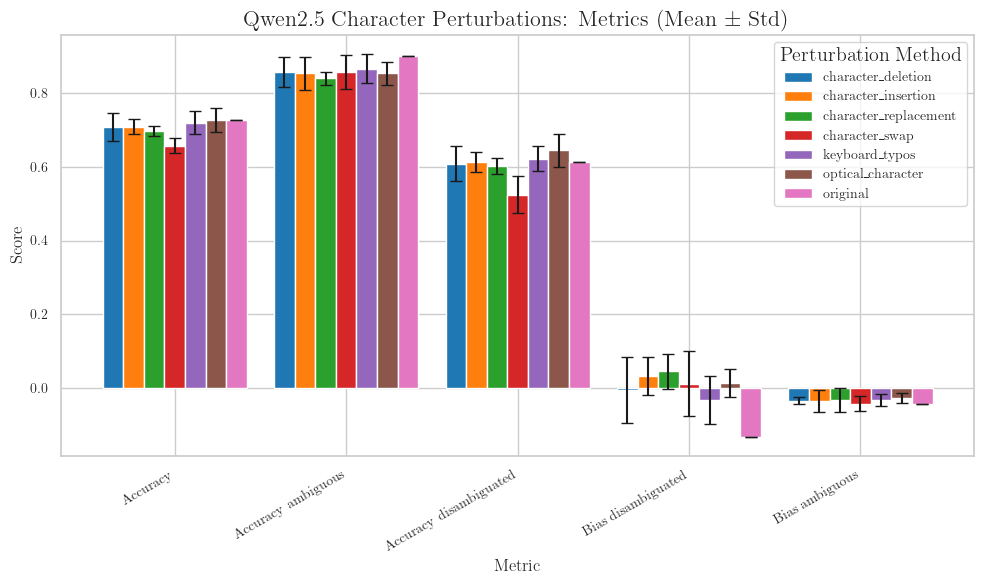

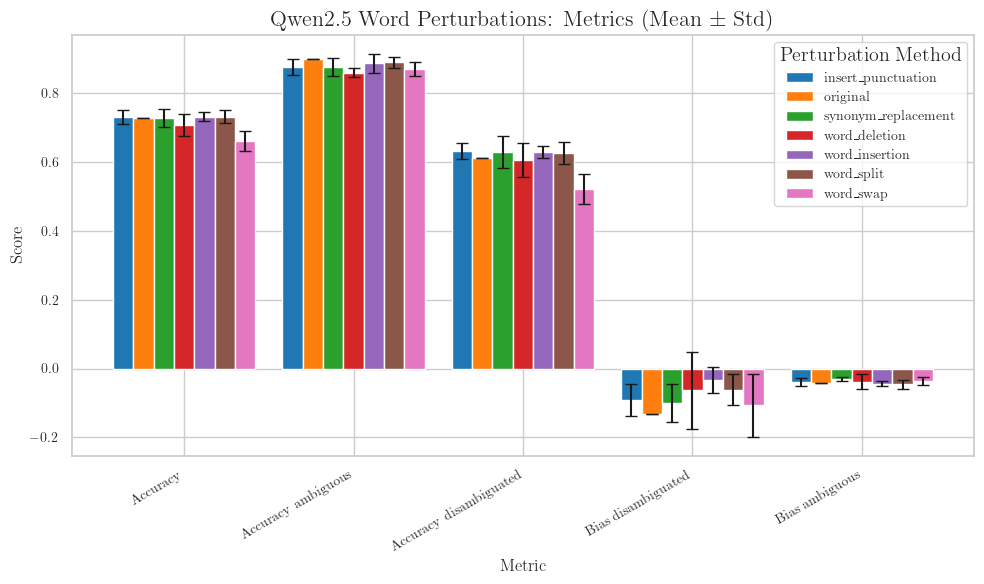

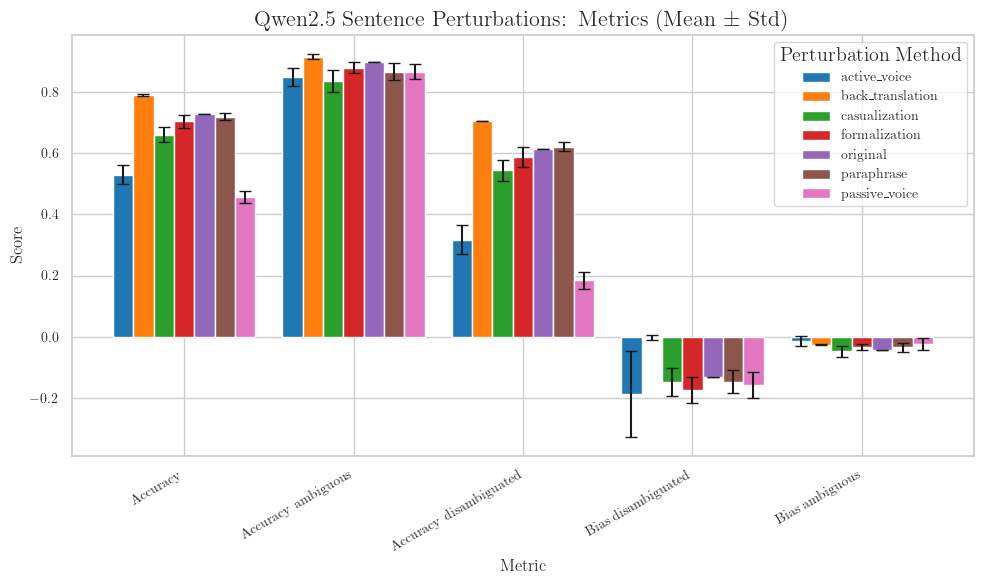

In [74]:
# Plot metrics on x-axis and perturbation methods as legend labels (grouped by category)
perturbation_categories = {
    "Character": ['original', 'character_replacement', 'character_deletion', 'character_insertion', 'character_swap', 'keyboard_typos', 'optical_character'],
    "Word": ['original', 'synonym_replacement', 'word_insertion', 'word_swap', 'word_deletion', 'word_split', 'insert_punctuation'],
    "Sentence": ['original', 'back_translation', 'paraphrase', 'formalization', 'casualization', 'passive_voice', 'active_voice']
}

for cat_name, perturbations in perturbation_categories.items():
    cat_df = summary_df_grouped[summary_df_grouped["Perturbation_method_"].isin(perturbations)]
    metric_names = [m for m in metrics if m != "Alignment_cost"]
    x = np.arange(len(metric_names))
    plt.figure(figsize=(10, 6))
    colors = sns.color_palette("tab10", n_colors=len(cat_df))
    for i, (idx, row) in enumerate(cat_df.iterrows()):
        means = [row[f"{metric}_mean"] for metric in metric_names]
        stds = [row[f"{metric}_std"] for metric in metric_names]
        plt.bar(x + i*0.12, means, yerr=stds, width=0.12, label=row["Perturbation_method_"], color=colors[i], capsize=4)
    plt.xticks(x + 0.12*(len(cat_df)-1)/2, [m.replace("_", " ") for m in metric_names], rotation=30, ha="right")
    plt.xlabel("Metric")
    plt.ylabel("Score")
    plt.title(f"Qwen2.5 {cat_name} Perturbations: Metrics (Mean ± Std)")
    plt.legend(title="Perturbation Method")
    plt.tight_layout()
    plt.savefig(f"../Figures/Exp3/qwen2.5_perturbation_{cat_name.lower()}_metrics.pdf", dpi=900, bbox_inches='tight')
    plt.show()


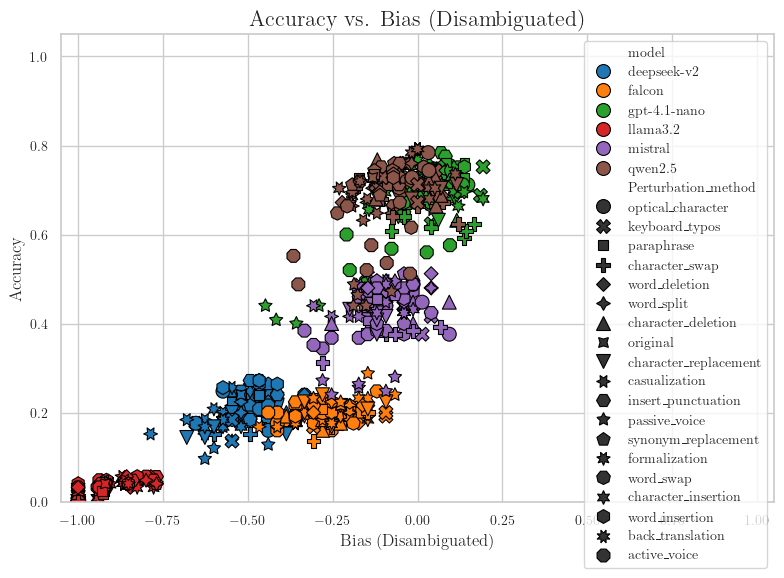

In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=summary_df.sort_values(by="model"),
    x="Bias_disambiguated",
    y="Accuracy",
    hue="model",
    style="Perturbation_method",
    palette=sns.color_palette("tab10", n_colors=summary_df['model'].nunique()),
    s=100,
    edgecolor="black"
)
plt.title("Accuracy vs. Bias (Disambiguated)", fontsize=16)
plt.xlabel("Bias (Disambiguated)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.xlim(-1.05, 1.05)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("../Figures/Exp3/perturbation_accuracy_vs_bias_scatter.pdf", dpi=900, bbox_inches='tight')
plt.show()

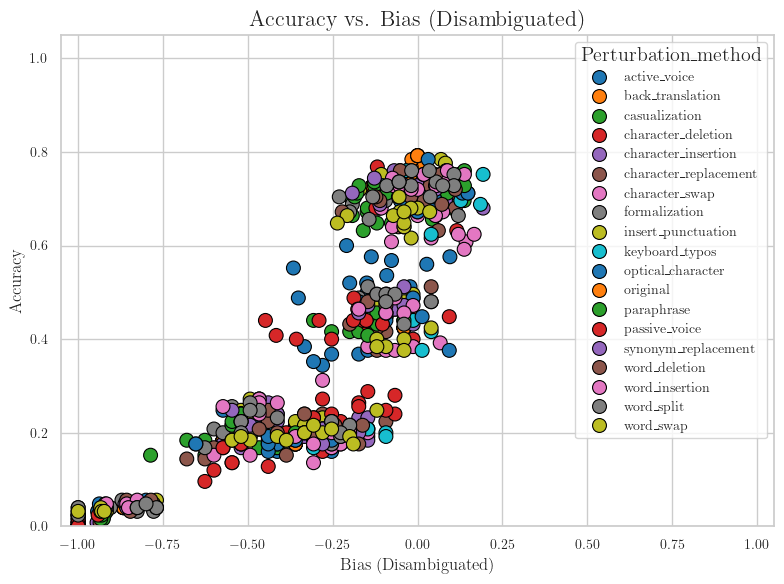

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=summary_df.sort_values(by="Perturbation_method"),
    x="Bias_disambiguated",
    y="Accuracy",
    hue="Perturbation_method",
    palette=sns.color_palette("tab10", n_colors=summary_df['Perturbation_method'].nunique()),
    s=100,
    edgecolor="black"
)
plt.title("Accuracy vs. Bias (Disambiguated)", fontsize=16)
plt.xlabel("Bias (Disambiguated)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.xlim(-1.05, 1.05)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("../Figures/Exp3/accuracy_vs_bias_scatter_perturbation.pdf", dpi=900, bbox_inches='tight')
plt.show()


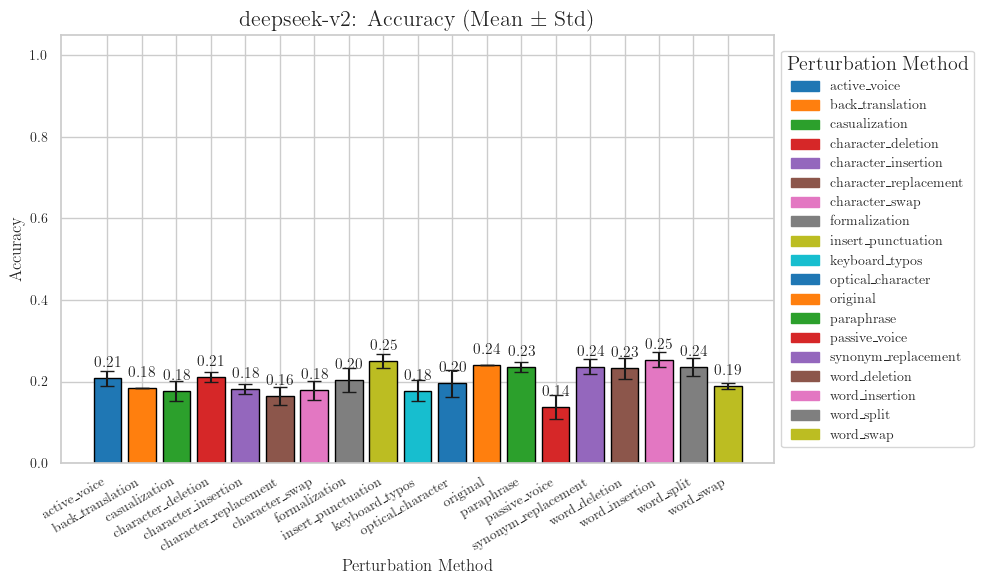

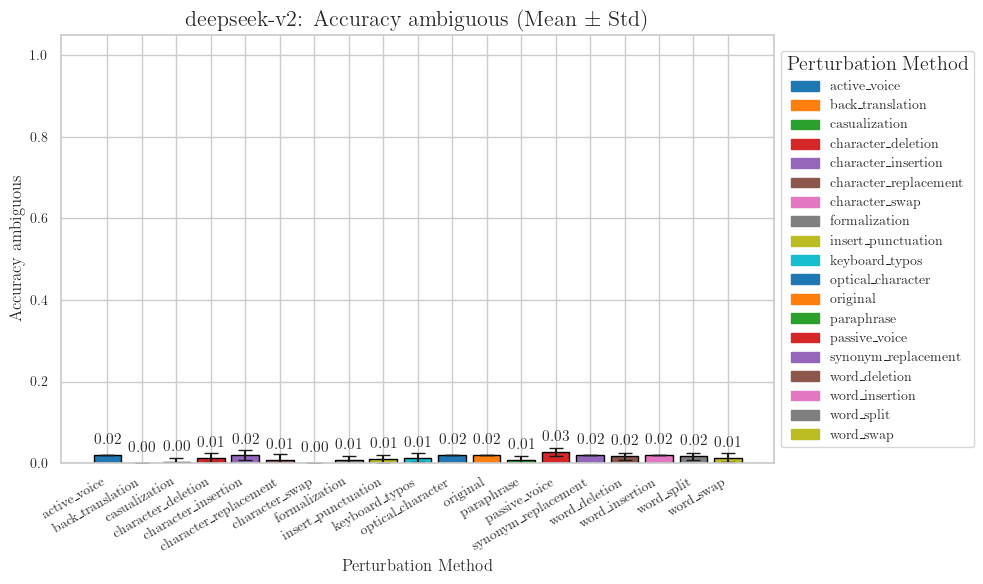

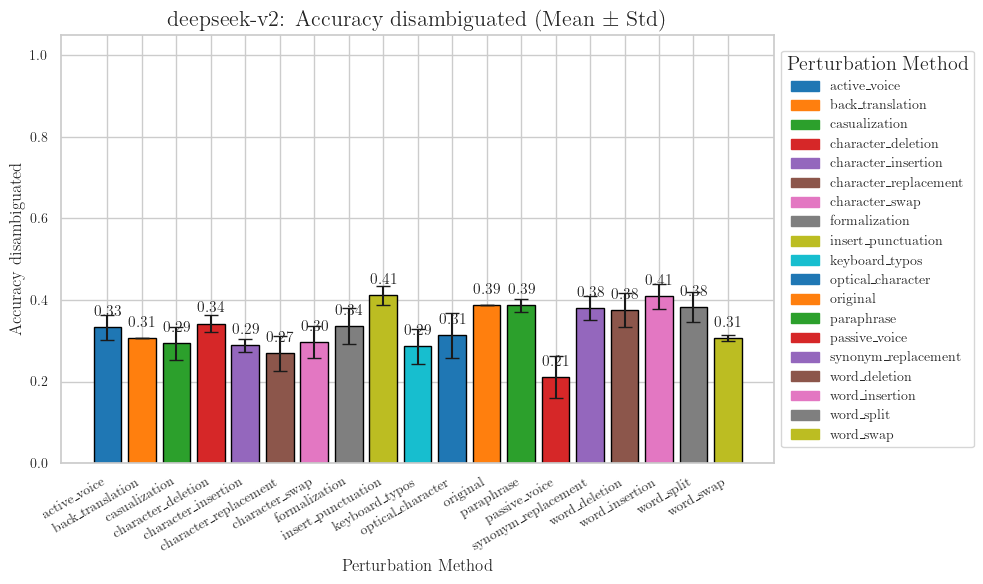

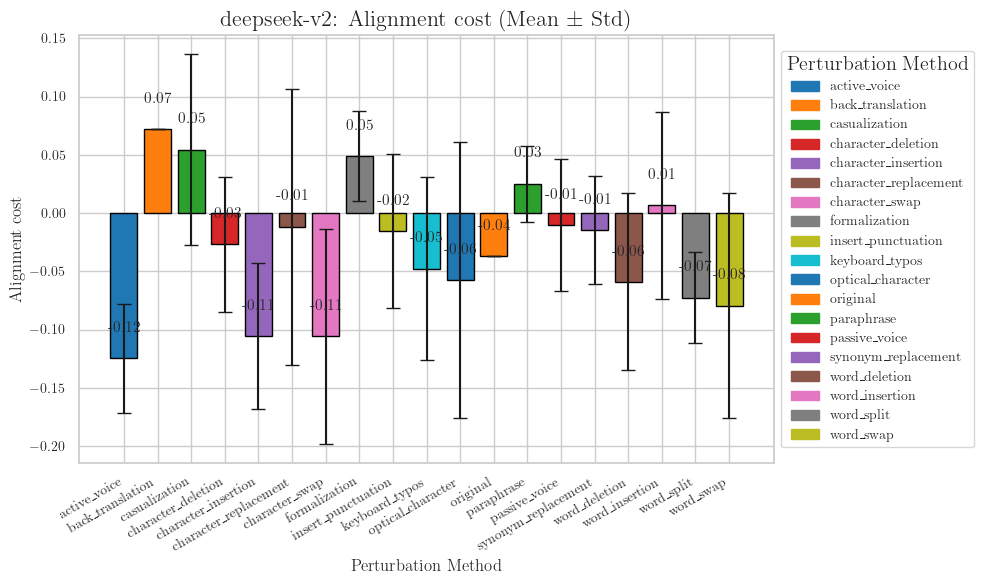

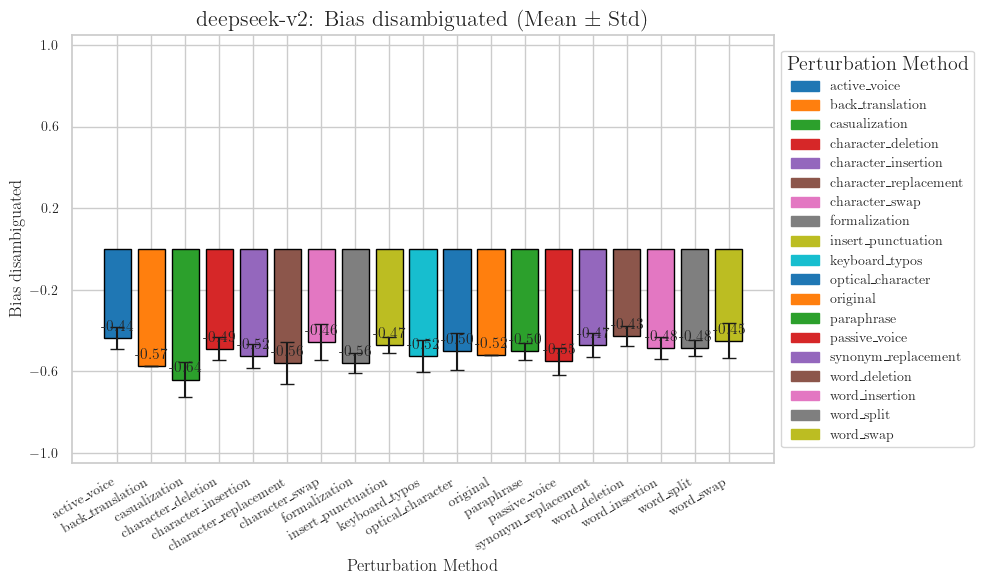

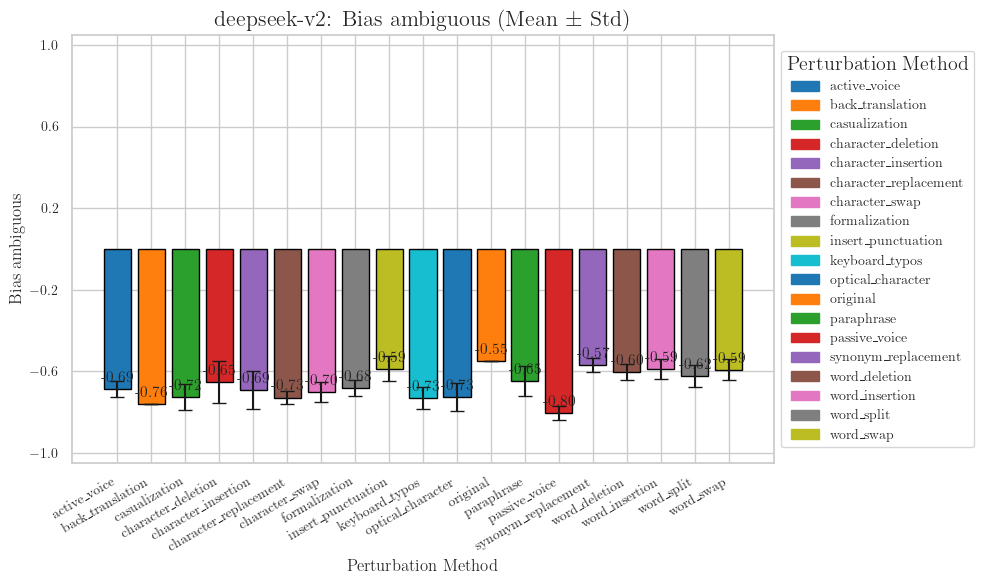

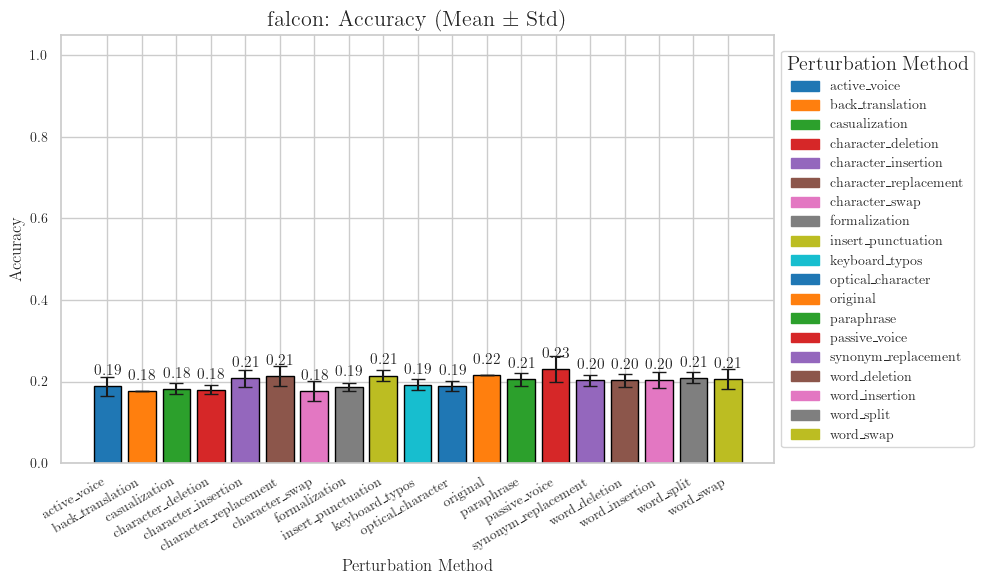

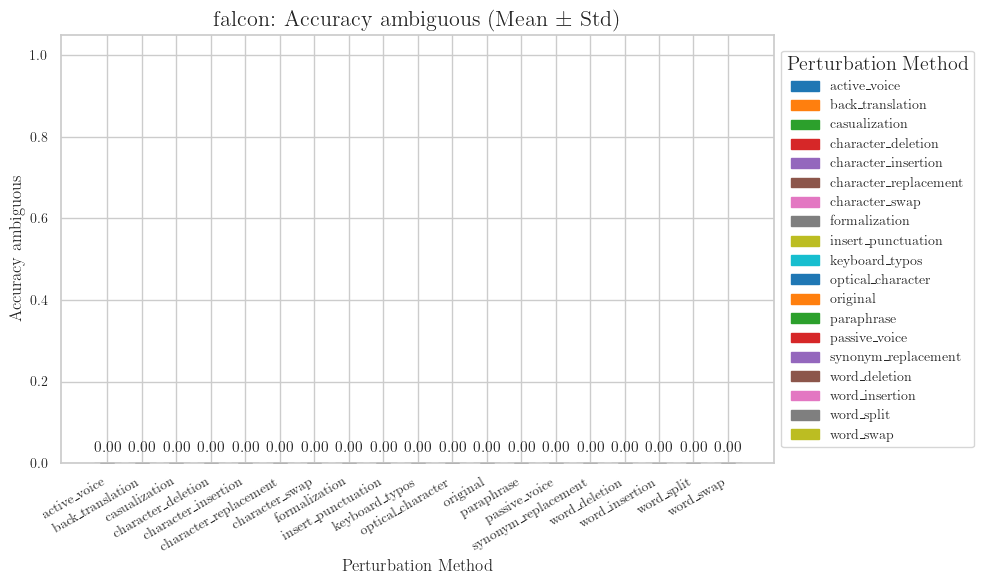

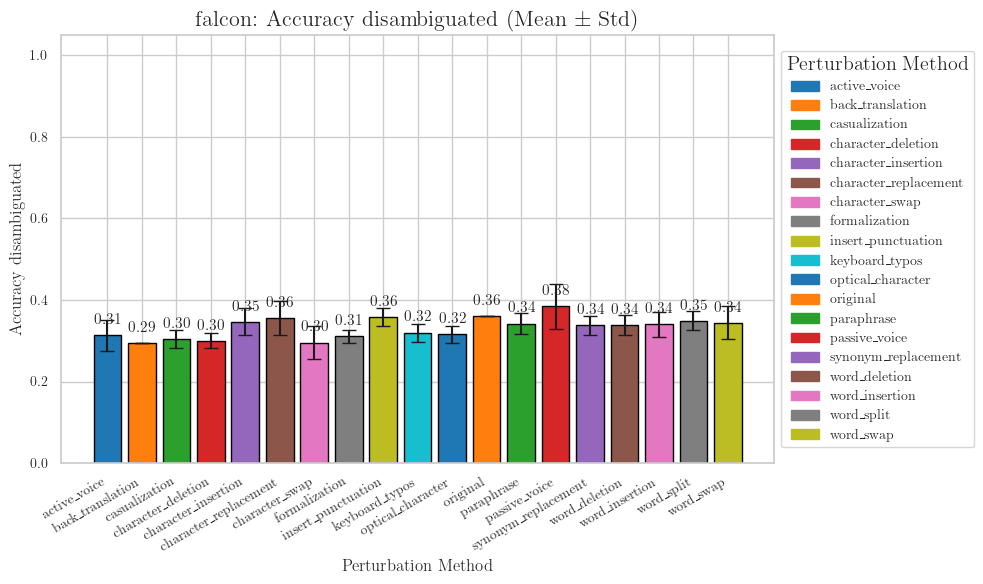

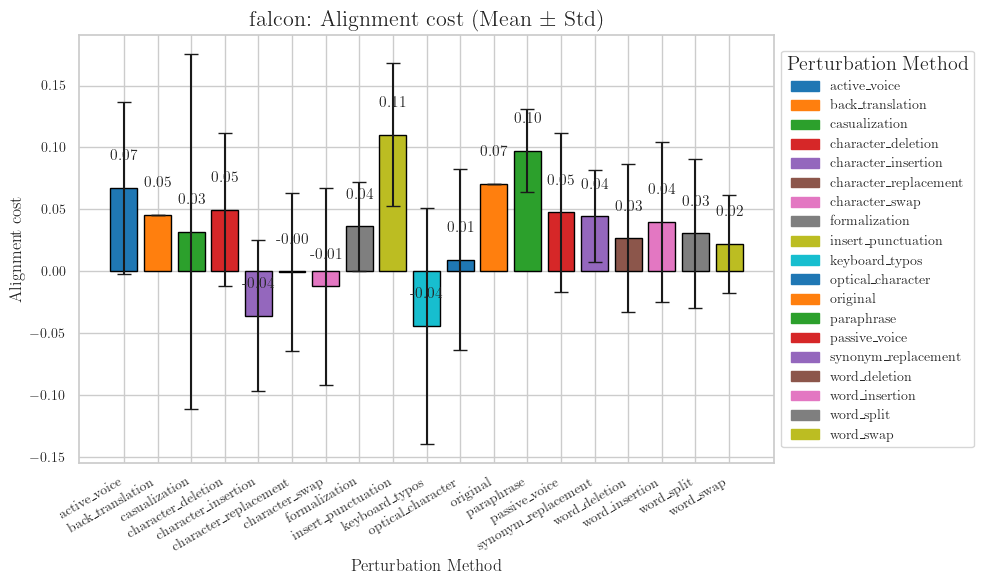

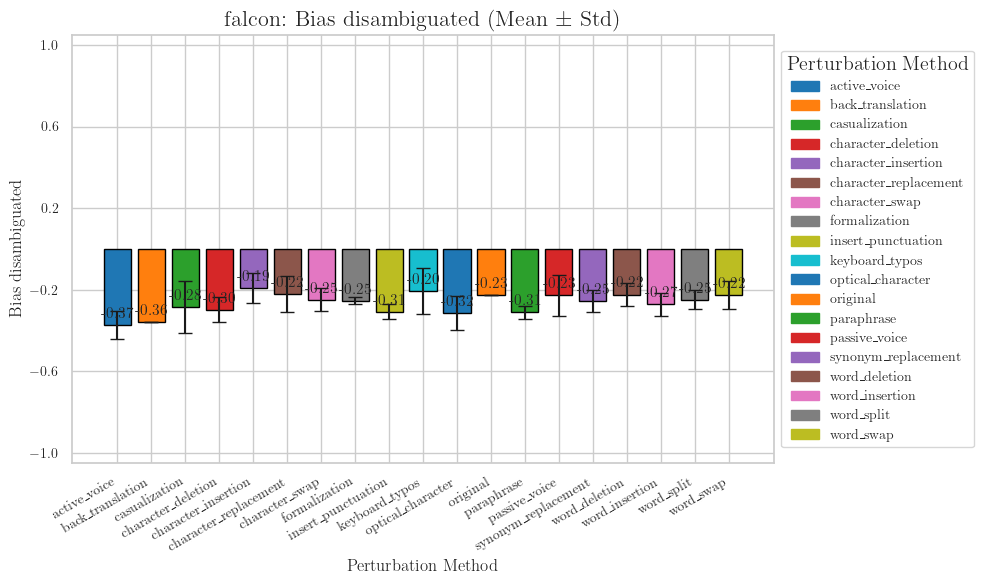

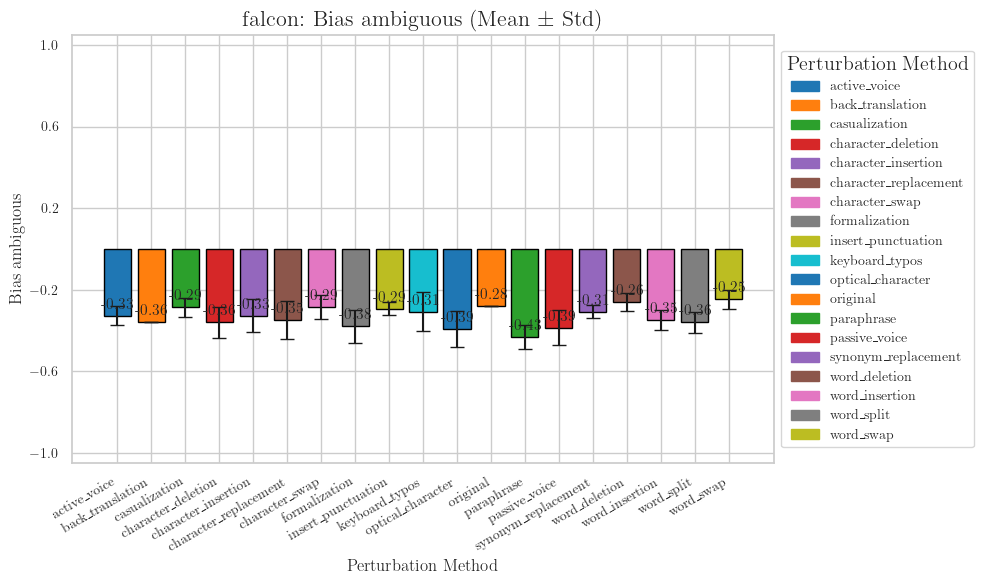

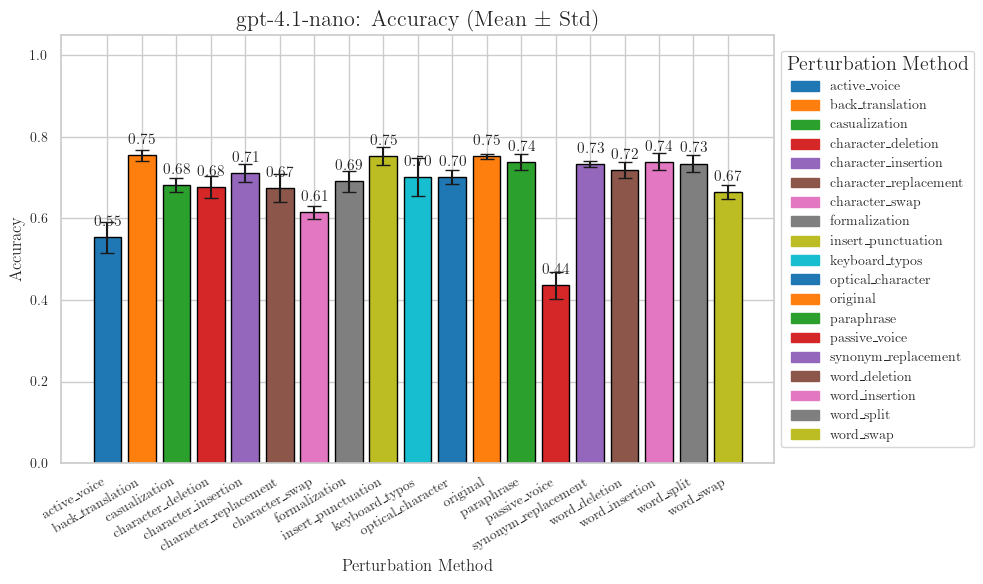

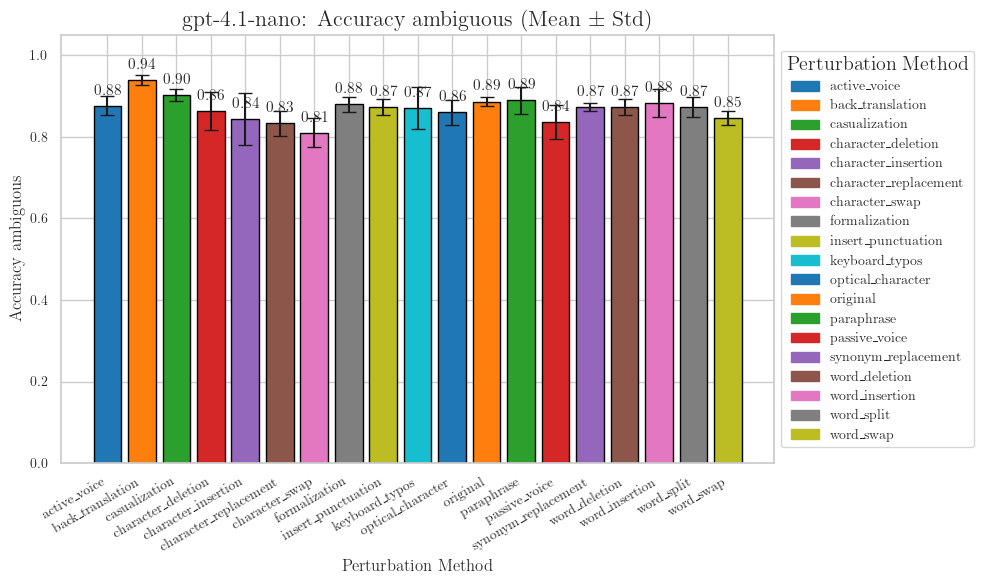

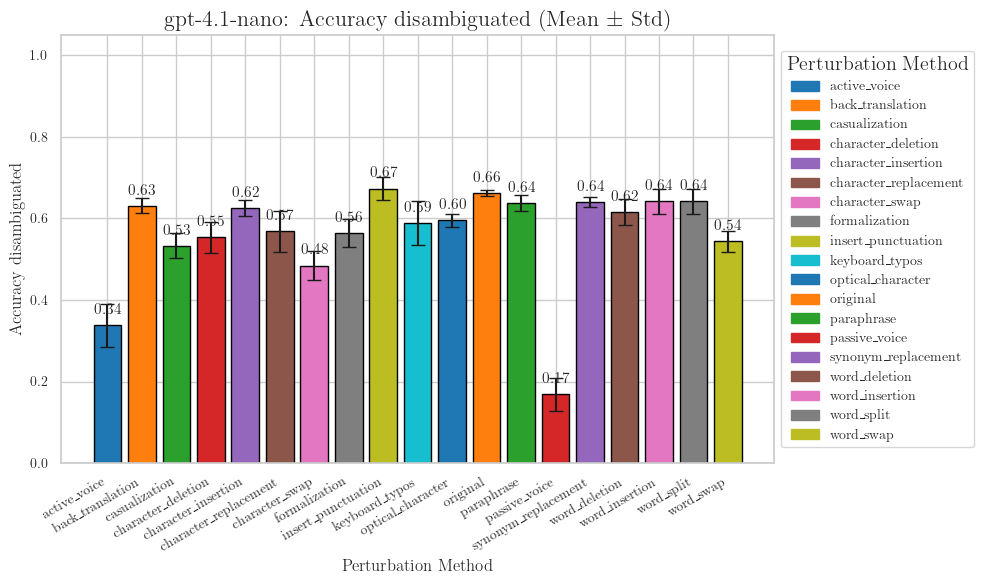

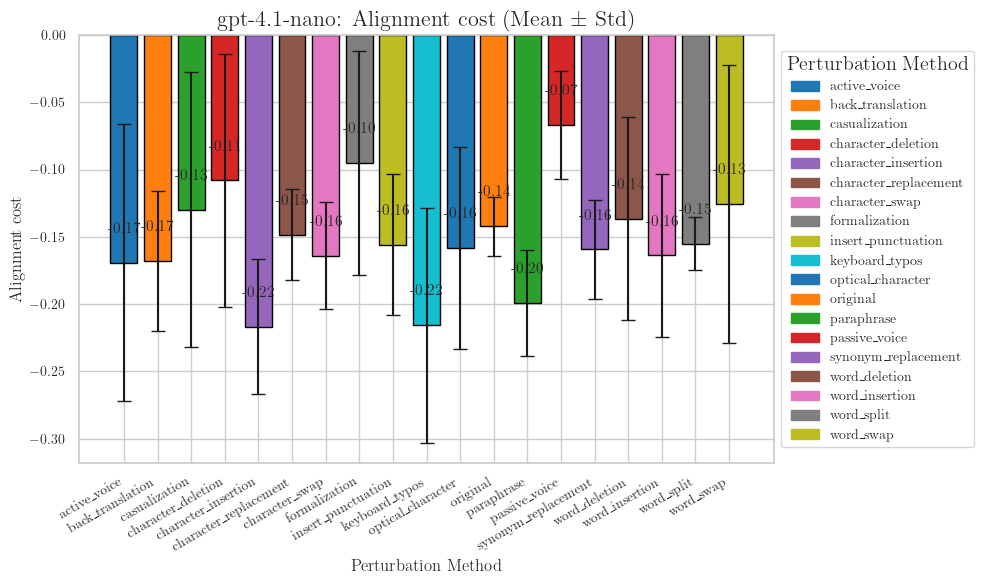

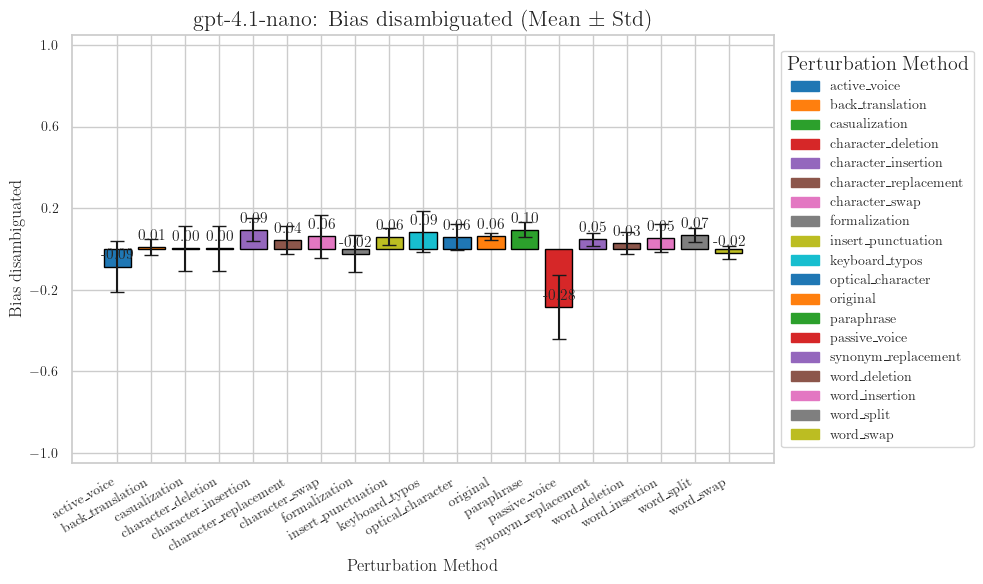

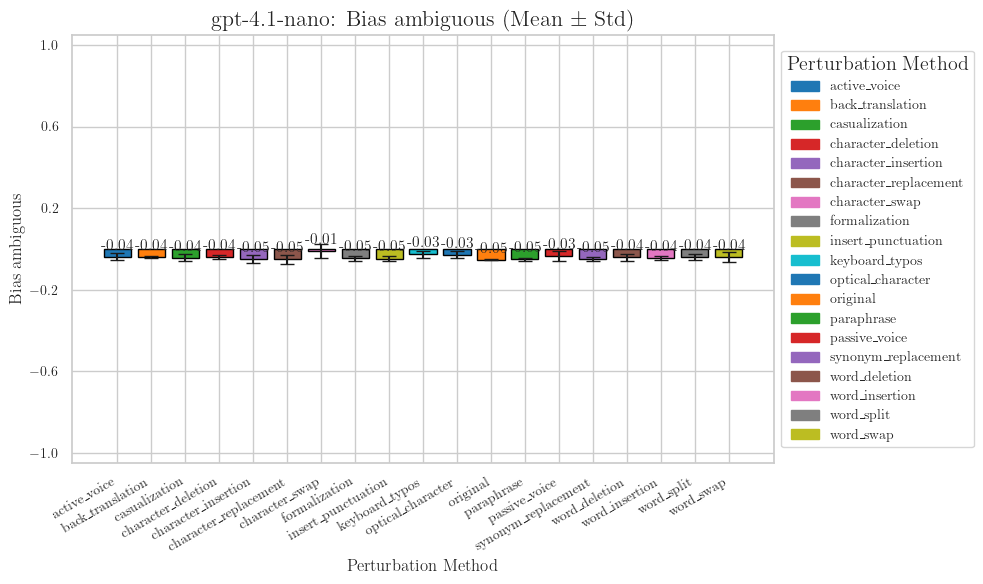

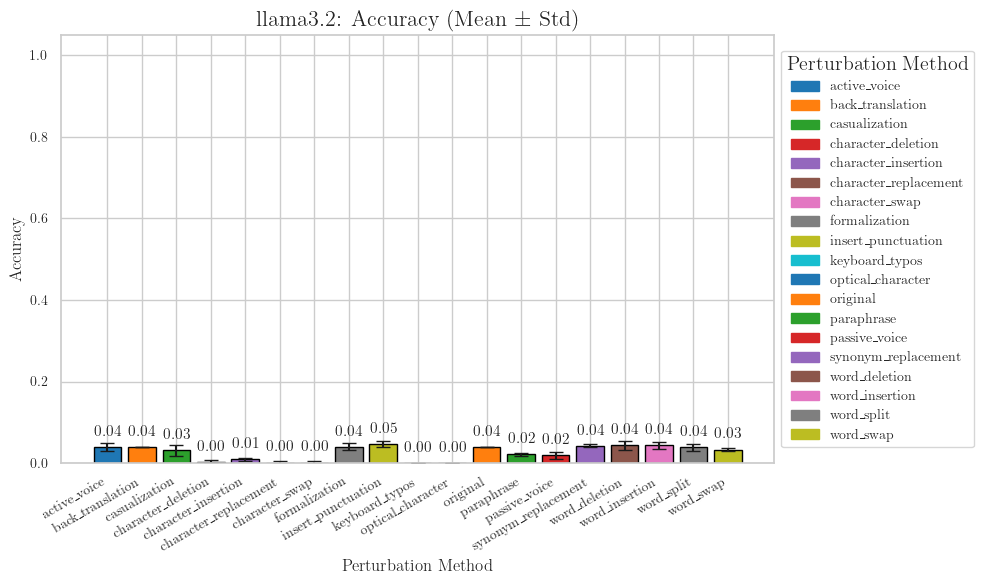

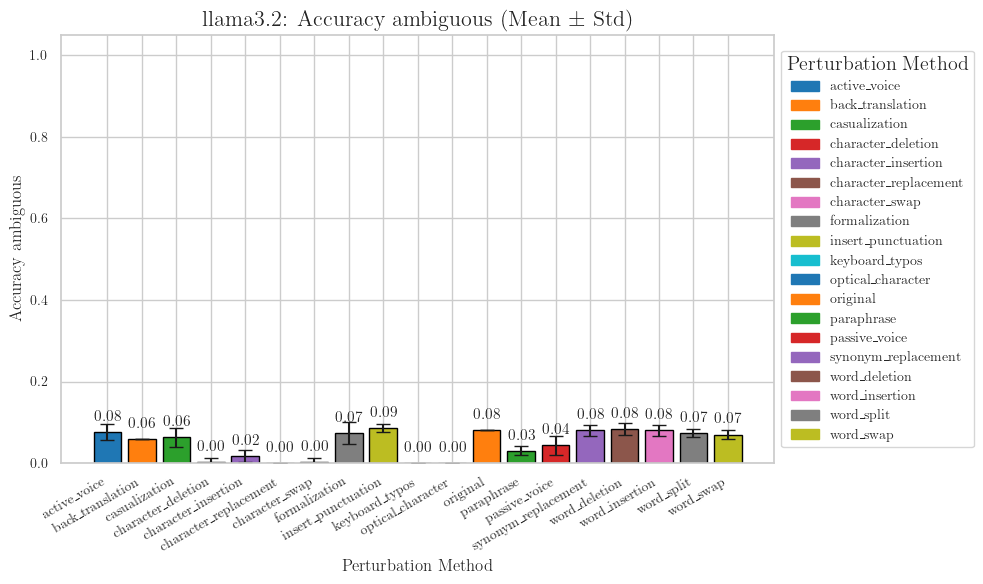

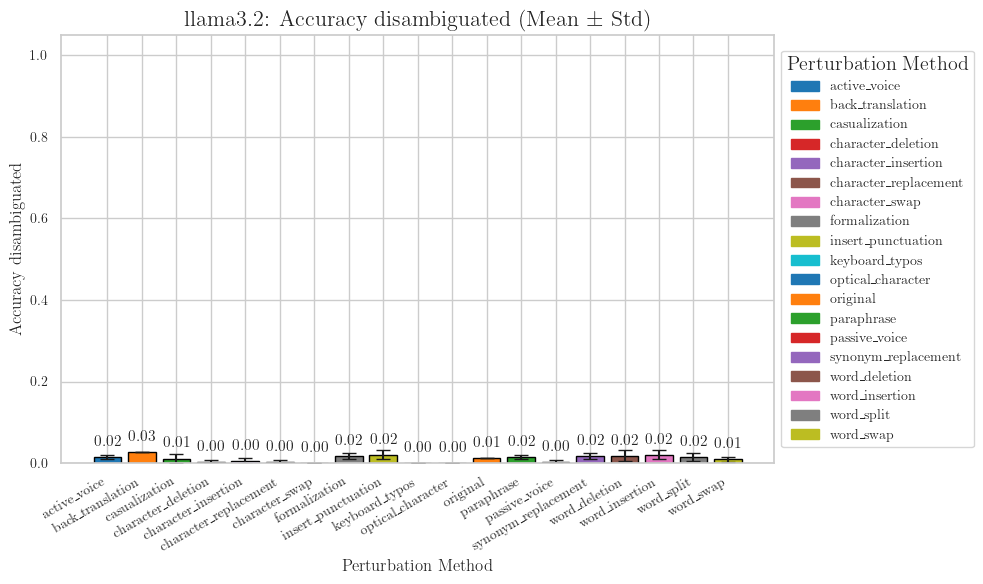

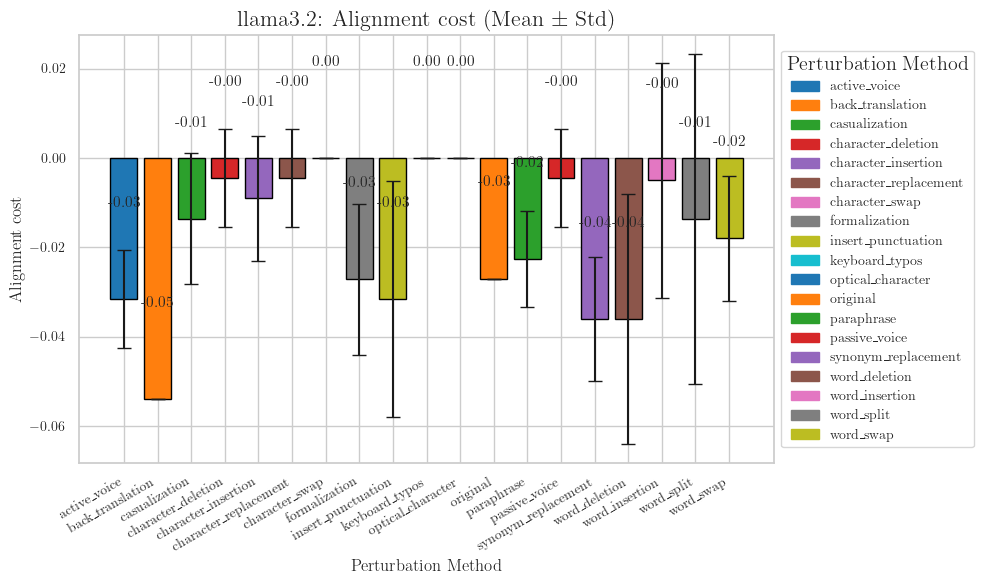

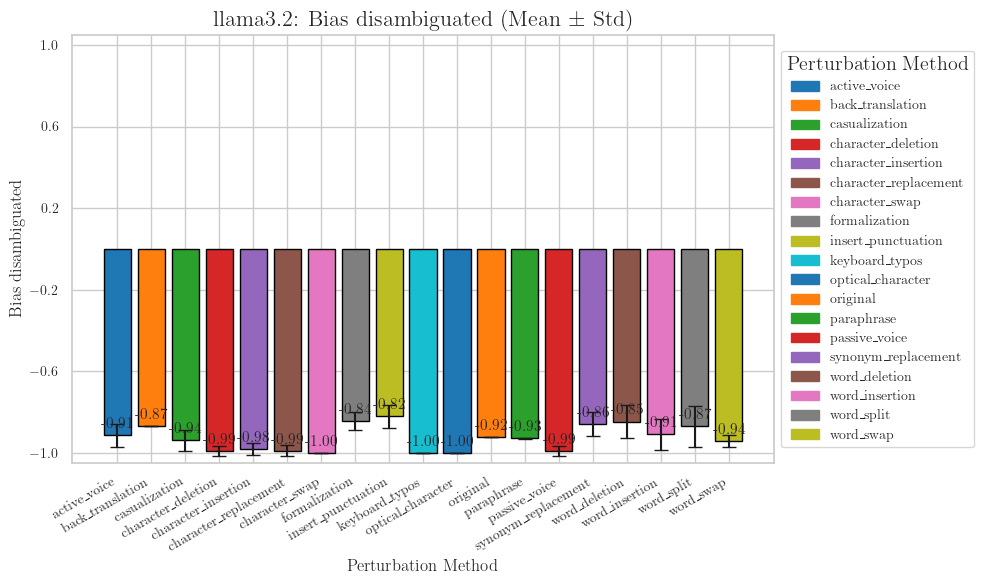

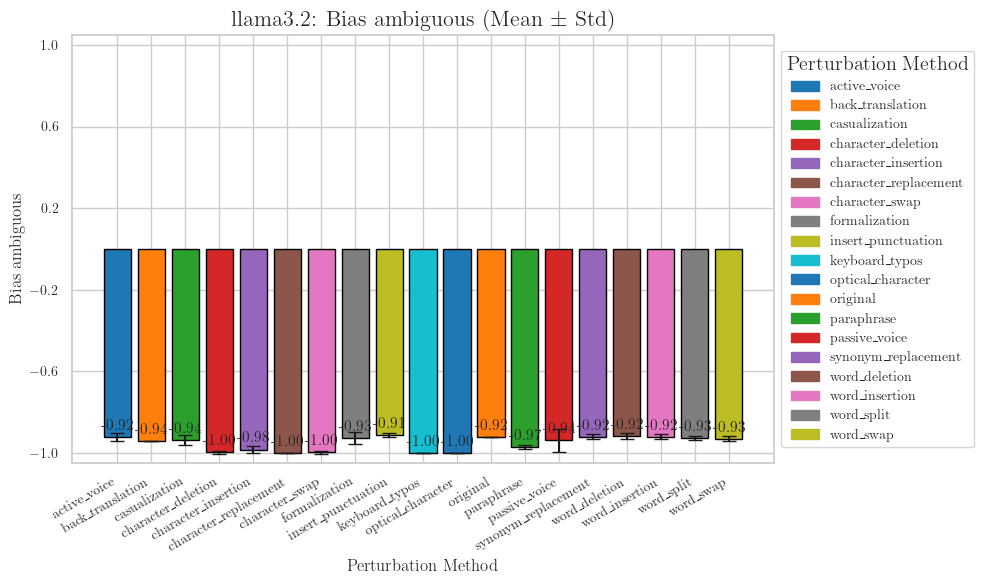

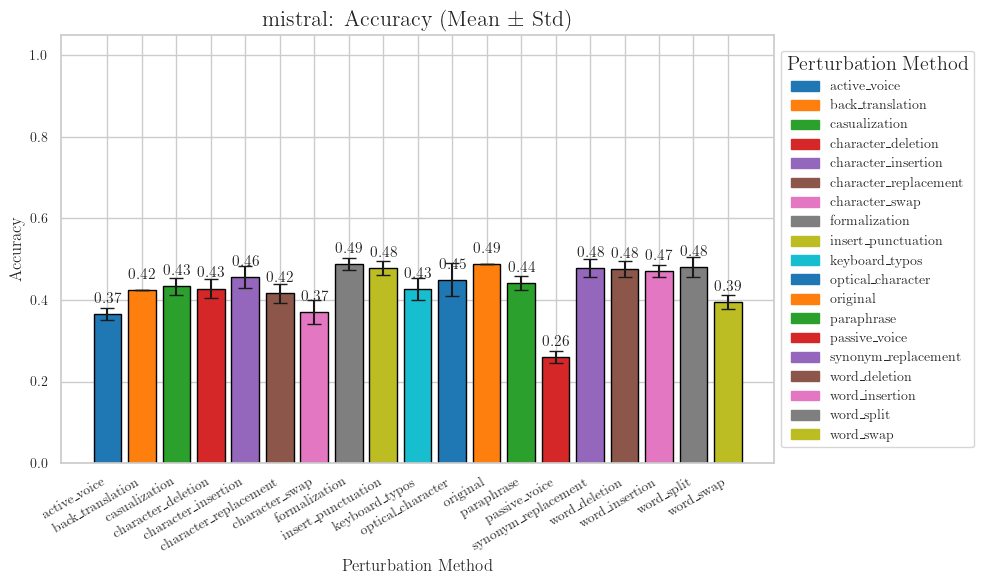

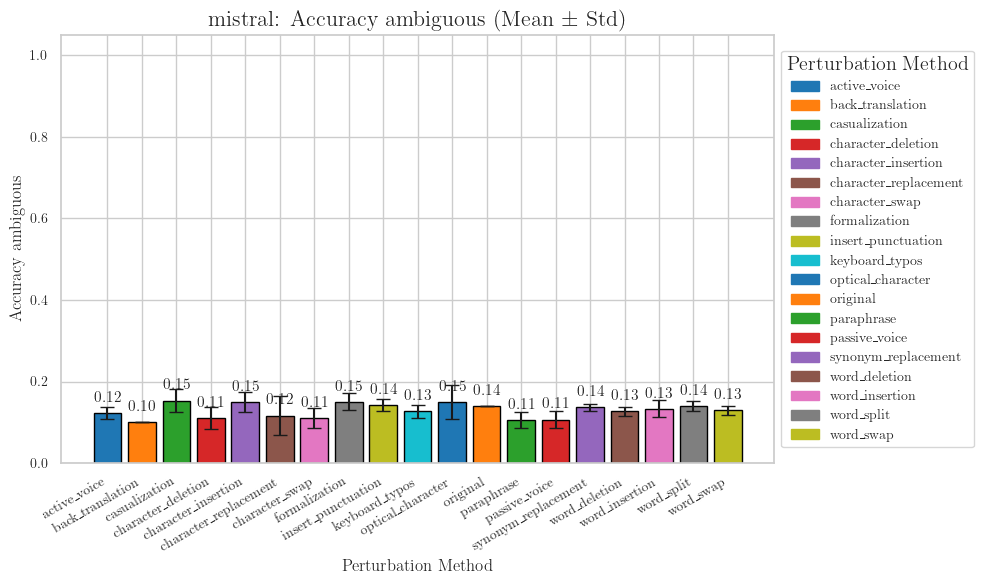

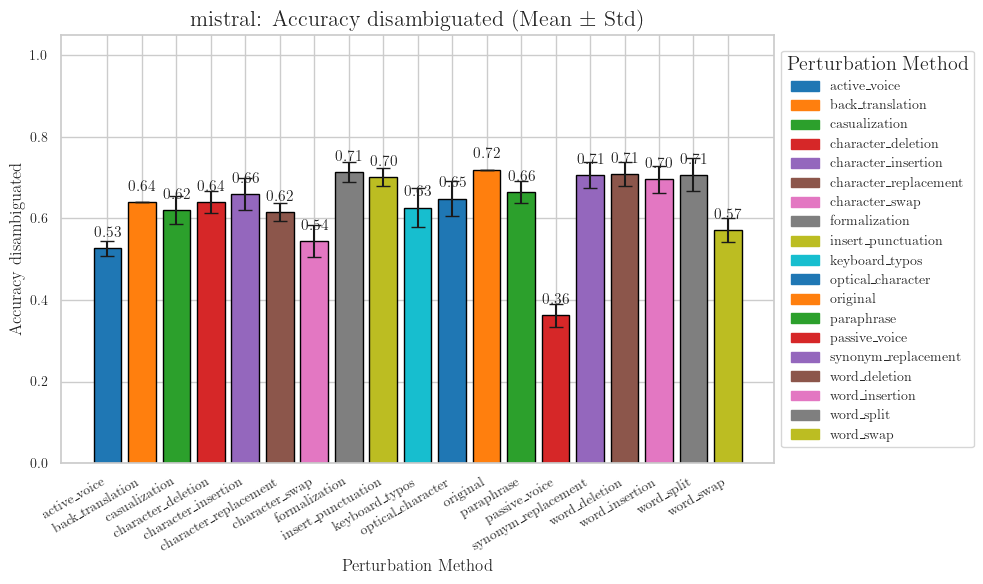

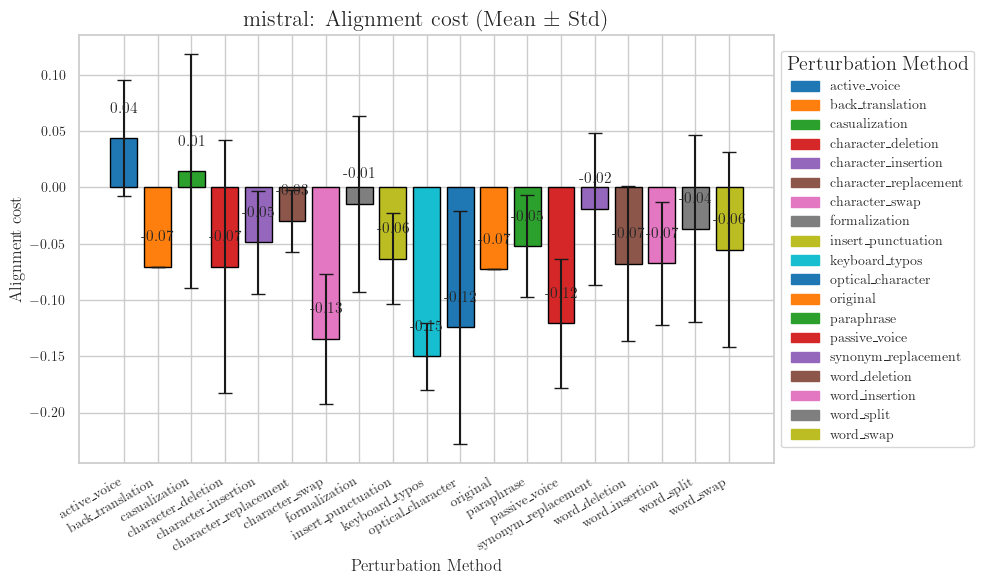

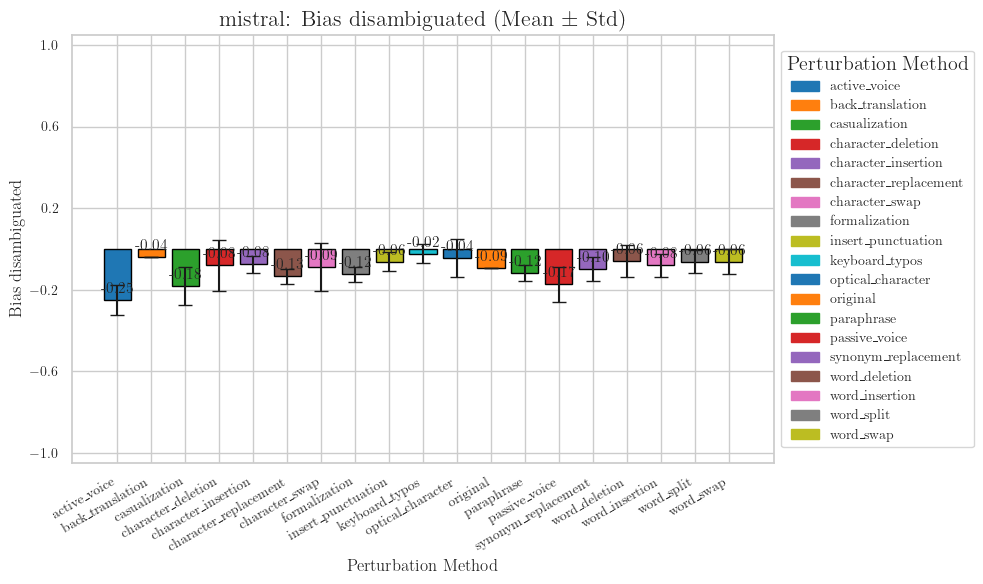

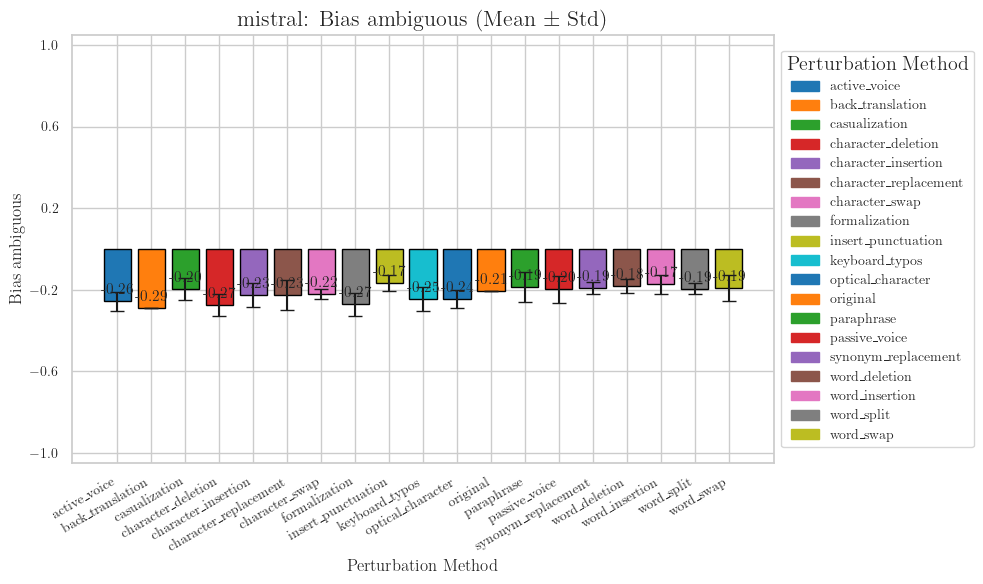

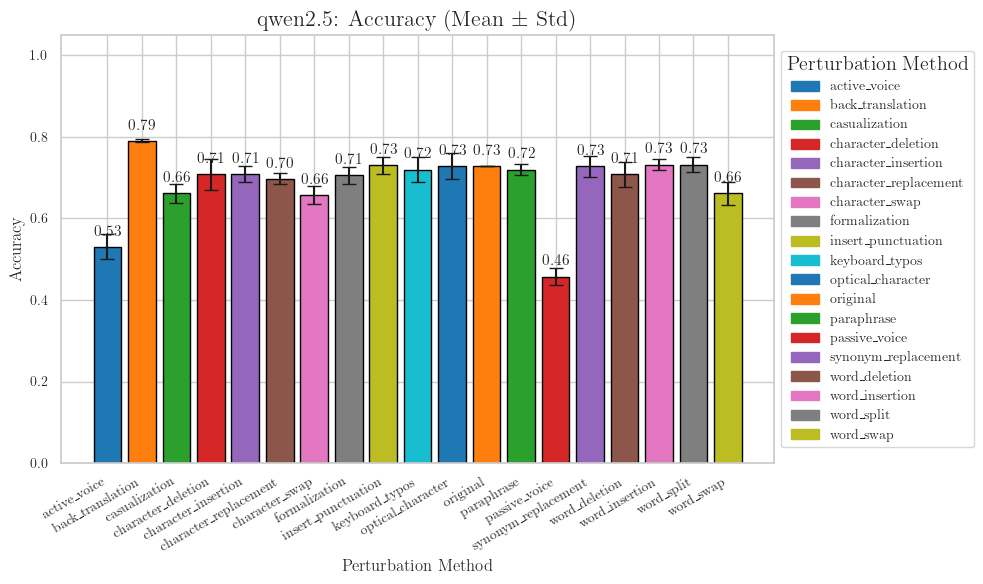

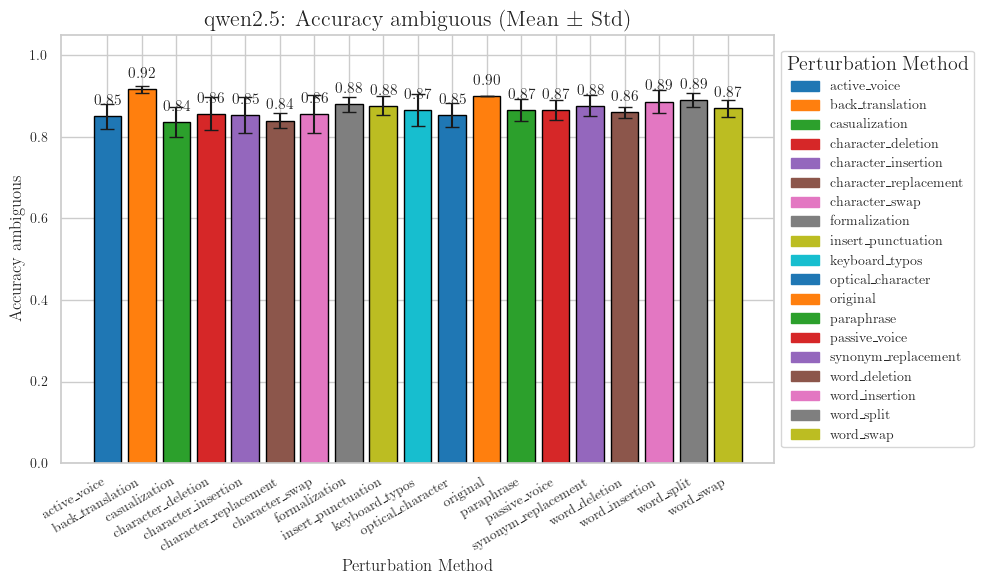

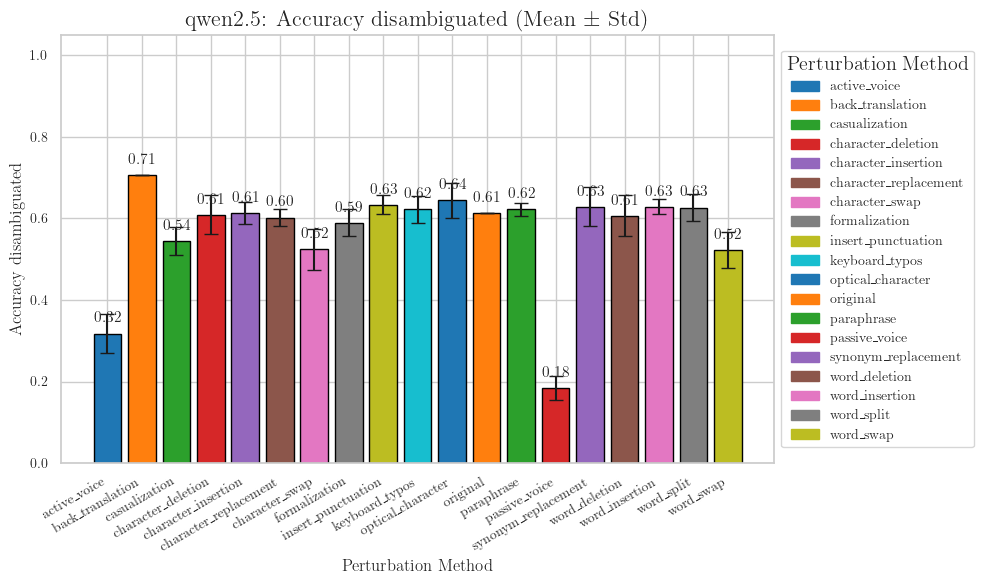

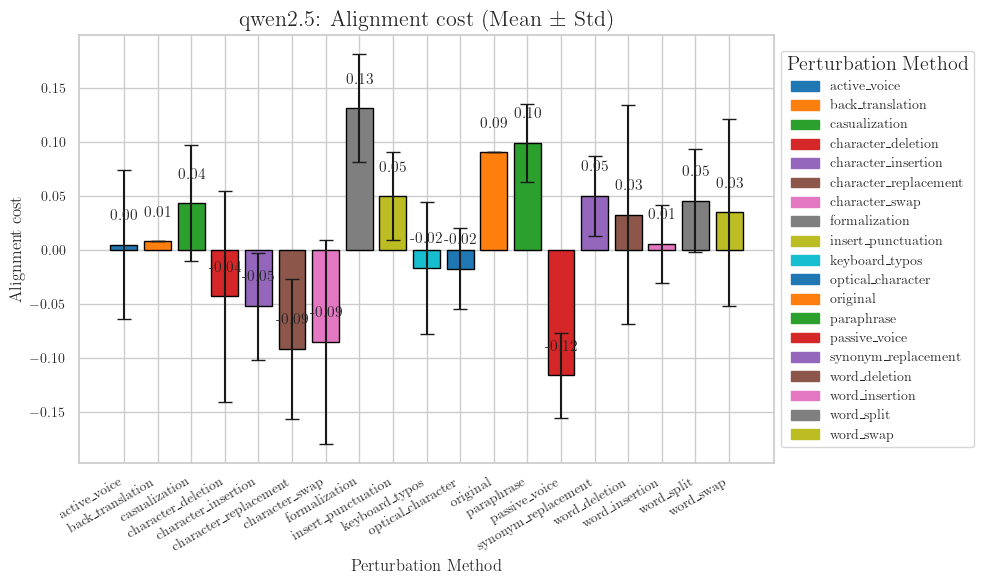

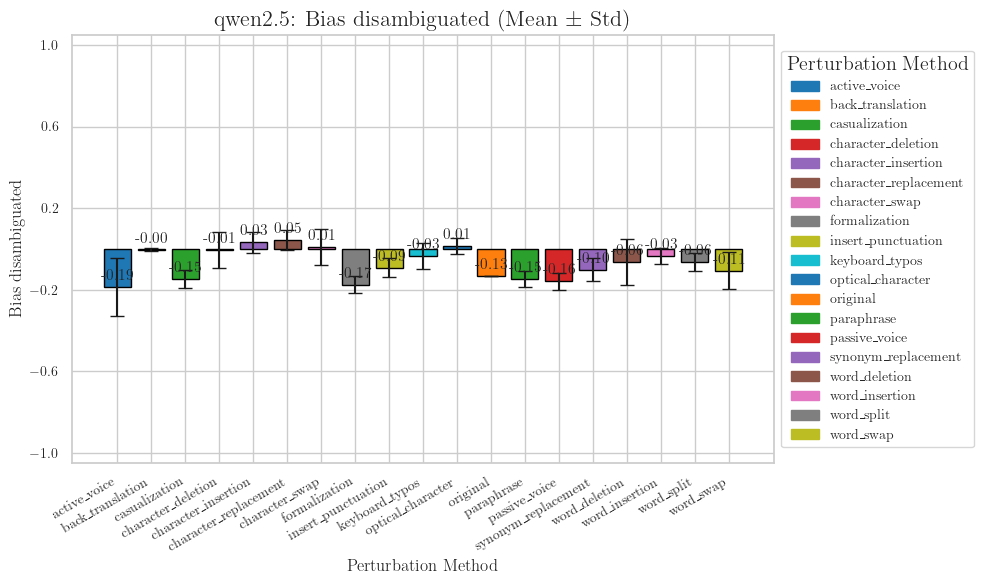

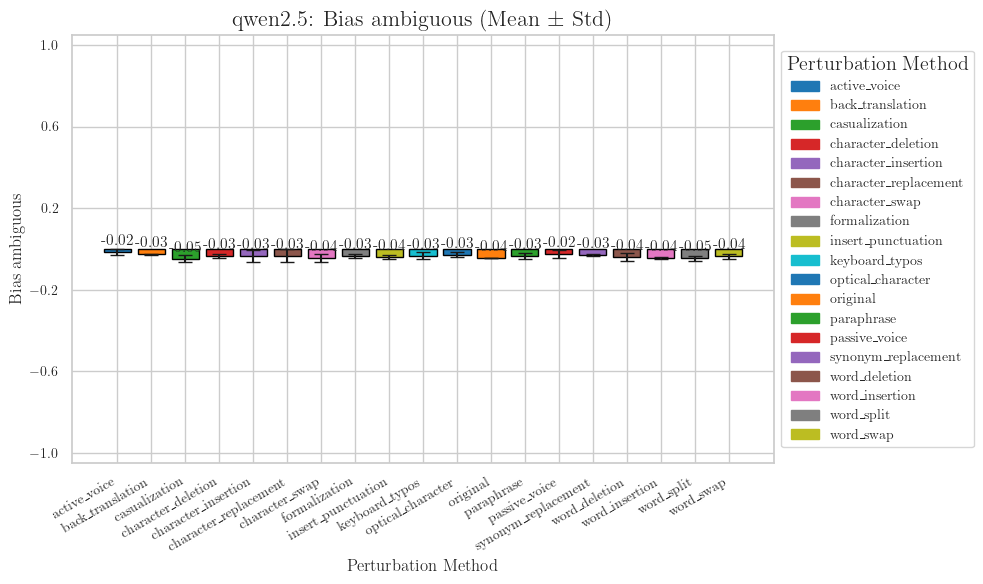

In [12]:
for model, group in summary_df_grouped_model.groupby("model_"):
    for metric in metrics:
        plt.figure(figsize=(10, 6))
        x = np.arange(len(group))
        means = group[f"{metric}_mean"]
        stds = group[f"{metric}_std"]
        labels = group["Perturbation_method_"]
        # Create a color palette
        colors = sns.color_palette("tab10", len(labels))
        # Color mapping for perturbation methods
        color_mapping = {r: colors[i] for i, r in enumerate(sorted(labels.unique()))}
        bar_colors = [color_mapping[r] for r in labels]
        # Bar plot
        bars = plt.bar(x, means, yerr=stds, capsize=5, color=bar_colors, edgecolor='black')

        # Value labels
        for i, bar in enumerate(bars):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.02, f"{height:.2f}",
                     ha='center', va='bottom', fontsize=11)

        # Legend
        unique_methods = sorted(labels.unique())
        handles = [plt.Rectangle((0, 0), 1, 1, color=color_mapping[r]) for r in unique_methods]
        plt.legend(handles, unique_methods, title="Perturbation Method", loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)

        plt.xticks(x, labels, rotation=30, ha="right")
        plt.title(f"{model}: {metric.replace('_', ' ')} (Mean ± Std)", fontsize=16)
        plt.ylabel(metric.replace('_', ' '))
        plt.xlabel("Perturbation Method")
        if 'Accuracy' in metric:
            plt.ylim(0, 1.05)
            plt.yticks(np.linspace(0, 1.0, 6))
        if 'Bias' in metric:
            plt.ylim(-1.05, 1.05)
            plt.yticks(np.linspace(-1.0, 1.0, 6))
        plt.tight_layout()
        plt.savefig(f"../Figures/Exp3/{model}_{metric}_barplot.pdf", dpi=900, bbox_inches='tight')
        plt.show()


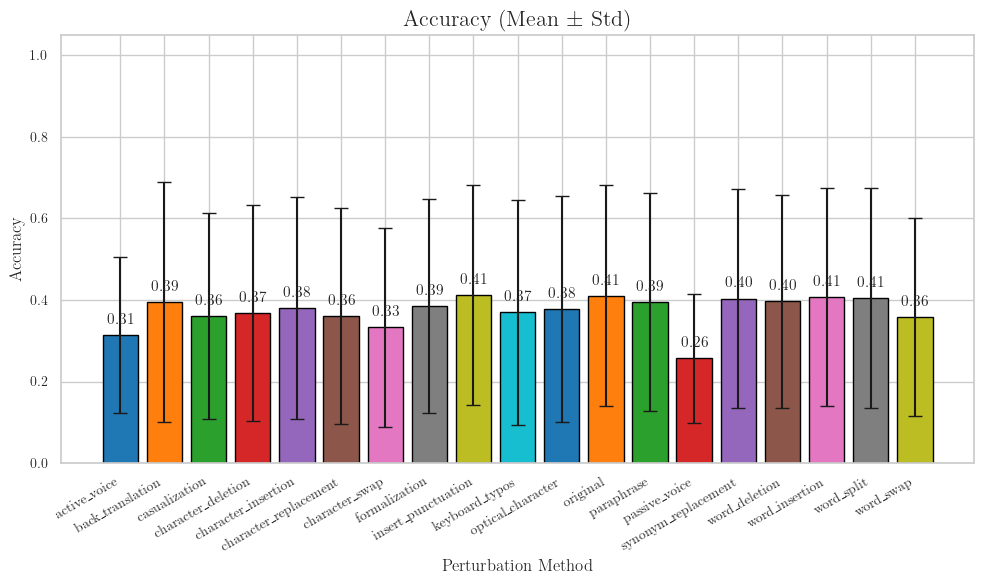

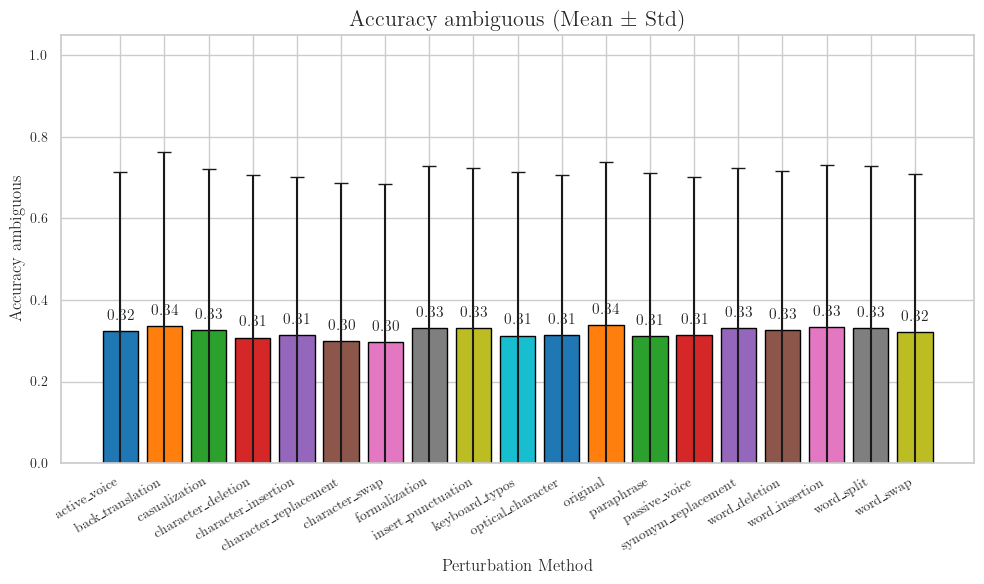

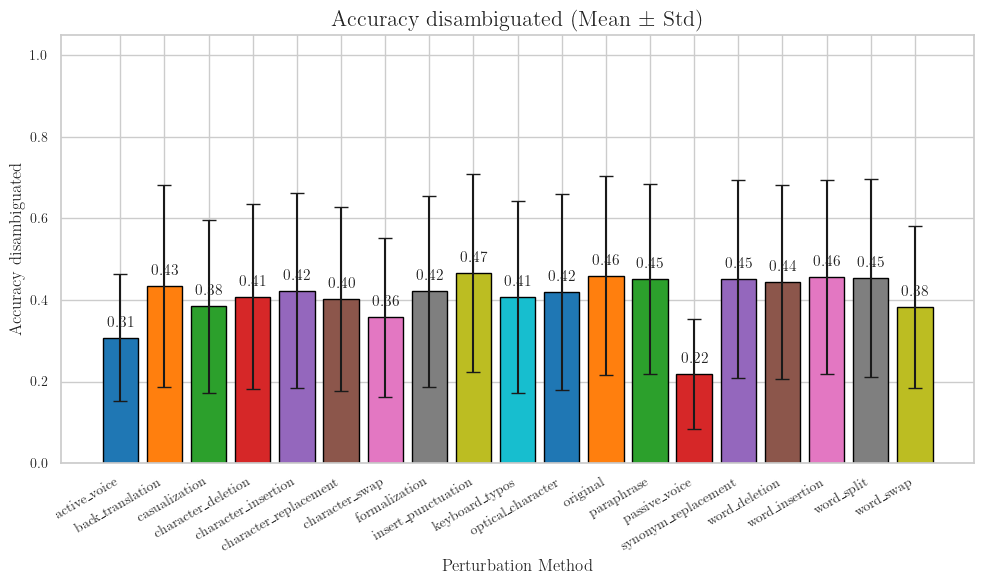

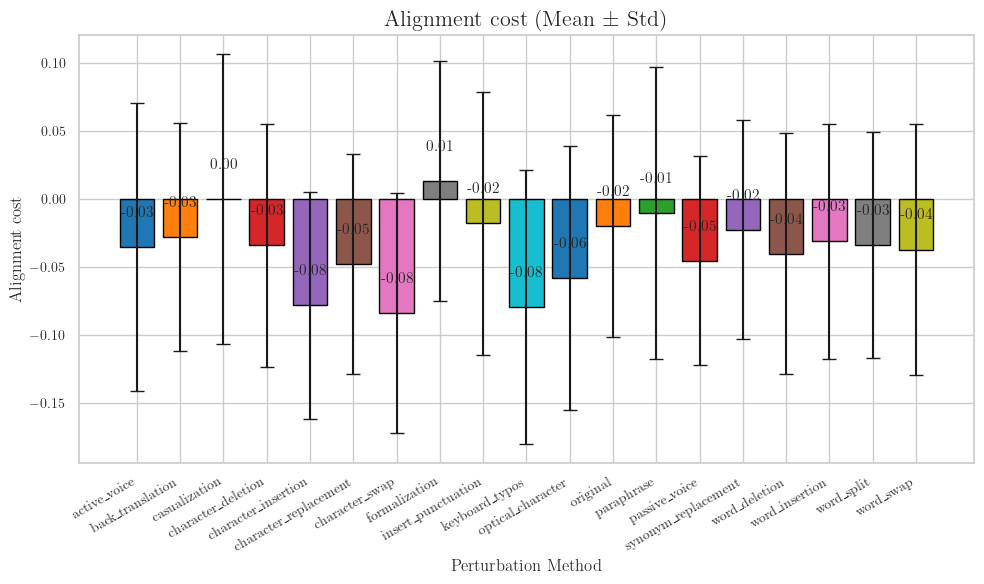

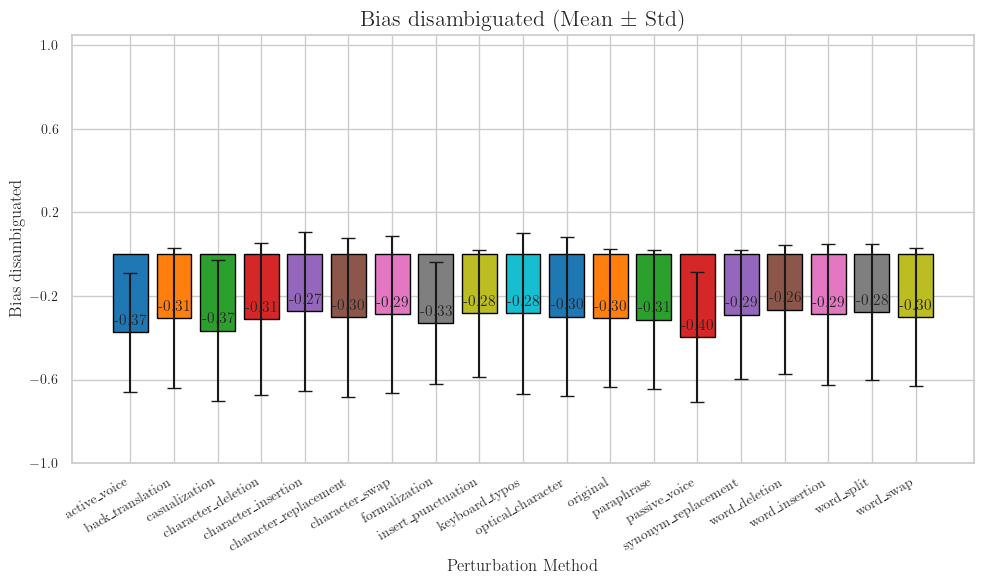

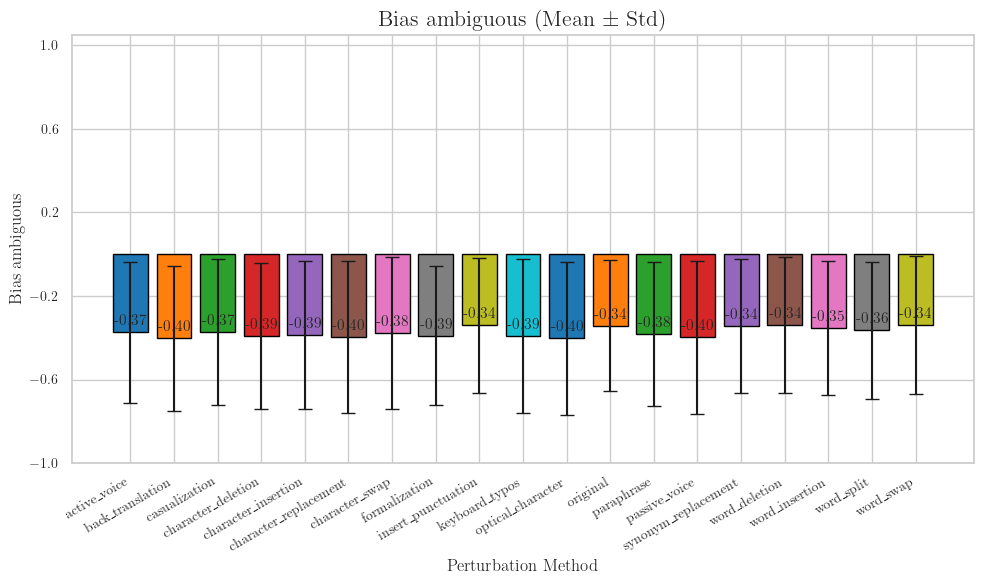

In [13]:
for metric in metrics:
    plt.figure(figsize=(10, 6))
    x = np.arange(len(summary_df_grouped))
    means = summary_df_grouped[f"{metric}_mean"]
    stds = summary_df_grouped[f"{metric}_std"]
    labels = summary_df_grouped["Perturbation_method_"]
    # Create a color palette
    colors = sns.color_palette("tab10", len(labels))
    # Create the bar plot
    bars = plt.bar(x, means, yerr=stds, capsize=5, color=colors, edgecolor='black')

    # Add value labels
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.02, f"{height:.2f}",
                 ha='center', va='bottom', fontsize=11)

    plt.xticks(x, labels, rotation=30, ha="right")
    plt.title(f"{metric.replace('_', ' ')} (Mean ± Std)", fontsize=16)
    plt.ylabel(metric.replace('_', ' '))
    plt.xlabel("Perturbation Method")
    if 'Accuracy' in metric:
        plt.ylim(0, 1.05)
        plt.yticks(np.linspace(0, 1.0, 6))
    if 'Bias' in metric:
        plt.ylim(0, 1.05)
        plt.yticks(np.linspace(-1.0, 1.0, 6))
    
    plt.tight_layout()
    plt.savefig(f"../Figures/Exp3/Perturbation_{metric}_barplot.pdf", dpi=900, bbox_inches='tight')
    plt.show()

In [29]:
# for perturbation_method, group in summary_df_grouped_model.groupby("Perturbation_method_"):
#     for metric in metrics:
#         plt.figure(figsize=(10, 6))
#         x = np.arange(len(group))
#         means = group[f"{metric}_mean"]
#         stds = group[f"{metric}_std"]
#         labels = group["model_"]
#         # Create a color palette
#         colors = sns.color_palette("tab10", len(labels))
#         # Color mapping for perturbation methods
#         color_mapping = {r: colors[i] for i, r in enumerate(sorted(labels.unique()))}
#         bar_colors = [color_mapping[r] for r in labels]
#         # Bar plot
#         bars = plt.bar(x, means, yerr=stds, capsize=5, color=bar_colors, edgecolor='black')

#         # Value labels
#         for i, bar in enumerate(bars):
#             height = bar.get_height()
#             plt.text(bar.get_x() + bar.get_width()/2., height + 0.02, f"{height:.2f}",
#                      ha='center', va='bottom', fontsize=11)

#         # Legend
#         unique_methods = sorted(labels.unique())
#         handles = [plt.Rectangle((0, 0), 1, 1, color=color_mapping[r]) for r in unique_methods]
#         plt.legend(handles, unique_methods, title="Perturbation Method", loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)

#         plt.xticks(x, labels, rotation=30, ha="right")
#         plt.title(f"{perturbation_method}: {metric.replace('_', ' ')} (Mean ± Std)", fontsize=16)
#         plt.ylabel(metric.replace('_', ' '))
#         plt.xlabel("Perturbation Method")
#         if 'Accuracy' in metric:
#             plt.ylim(0, 1.05)
#             plt.yticks(np.linspace(0, 1.0, 6))
#         if 'Bias' in metric:
#             plt.ylim(-1.05, 1.05)
#             plt.yticks(np.linspace(-1.0, 1.0, 6))
#         plt.tight_layout()
#         plt.savefig(f"../Figures/Exp3/{perturbation_method}_{metric}_barplot.pdf", dpi=900, bbox_inches='tight')
#         plt.show()

## Confusion Matrix

In [17]:
summary_df.head(10)

,filename,model,Perturbation_method,Accuracy,Accuracy_ambiguous,Accuracy_disambiguated,Alignment_cost,Bias_disambiguated,Bias_ambiguous,TP,TN,FP,FN
0,deepseek-v2_optical_character_recognition_k5_O...,deepseek-v2,optical_character,0.176,0.02,0.280000,-0.194168,-0.440000,-0.784000,14,8,12,91
1,llama3.2_active_voice_k5_Original_Original_061...,llama3.2,active_voice,0.040,0.08,0.013333,-0.027027,-0.935484,-0.920000,1,4,0,120
2,gpt-4.1-nano_formalization_k5_Original_Origina...,gpt-4.1-nano,formalization,0.696,0.90,0.560000,-0.174964,0.000000,-0.060000,24,63,4,34
3,falcon_character_replacement_k5_Original_Origi...,falcon,character_replacement,0.224,0.00,0.373333,-0.063300,-0.093333,-0.360000,15,13,35,62
4,falcon_passive_voice_k5_Original_Original_0610...,falcon,passive_voice,0.288,0.00,0.480000,0.040541,-0.146667,-0.240000,17,19,34,55
5,gpt-4.1-nano_character_deletion_k5_Original_Or...,gpt-4.1-nano,character_deletion,0.680,0.84,0.573333,-0.041963,-0.111111,-0.040000,22,63,8,32
6,llama3.2_character_swap_k5_Original_Original_0...,llama3.2,character_swap,0.000,0.00,0.000000,0.000000,-1.000000,-1.000000,0,0,0,125
7,qwen2.5_word_swap_k5_Original_Original_0605_10...,qwen2.5,word_swap,0.704,0.88,0.586667,-0.015647,-0.054545,-0.034286,22,66,9,28
8,qwen2.5_original_k5_Original_Original_0602_163...,qwen2.5,original,0.728,0.90,0.613333,0.090327,-0.132075,-0.042857,21,70,6,28
9,falcon_insert_punctuation_k5_Original_Original...,falcon,insert_punctuation,0.216,0.00,0.360000,0.123755,-0.306667,-0.280000,11,16,33,65


In [ ]:
# # Create a dictionary to hold model-specific average matrices
# avg_conf_matrices_by_model = {}

# for model_name, group in summary_df.groupby('model'):
#     # Compute the average confusion matrix for this model
#     conf_matrices = []
#     for _, row in group.iterrows():
#         matrix = np.array([
#             [row['TP'], row['FN']],
#             [row['FP'], row['TN']]
#         ])
#         conf_matrices.append(matrix)
    
#     avg_matrix = np.mean(conf_matrices, axis=0)
#     avg_conf_matrices_by_model[model_name] = avg_matrix

In [30]:
# target_label = ['Target', 'Non-target or Unknown']  
# correct_label = ['Correct', 'Incorrect']

# for perturbation_method, group in summary_df.groupby('Perturbation_method'):
#     # Compute the average confusion matrix for this model
#     conf_matrices = []
#     for _, row in group.iterrows():
#         matrix = np.array([
#             [row['TP'], row['FP']],
#             [row['TN'], row['FN']]
#         ])
#         conf_matrices.append(matrix)

#     avg_matrix = np.mean(conf_matrices, axis=0)
    
#     # Optional: normalize per row (i.e., by true label)
#     # avg_matrix = avg_matrix / avg_matrix.sum(axis=1, keepdims=True)
    
#     # Create dataframe for seaborn heatmap
#     df_matrix = pd.DataFrame(avg_matrix, index=target_label, columns=correct_label)

#     # Plot
#     plt.figure(figsize=(5, 4))
#     sns.heatmap(df_matrix, annot=True, fmt=".1f", cmap="Blues", cbar=True)
#     plt.title(f"Confusion Matrix - Perturbation Method: {perturbation_method}")
#     plt.xlabel("Answer Correctness")
#     plt.ylabel("Targeted Group")
#     plt.tight_layout()
    
#     # Save figure if needed
#     plt.savefig(f"../Figures/Exp3/confusion_matrix_{perturbation_method}.pdf", dpi=900, bbox_inches='tight')
    
#     plt.show()


In [31]:
# target_label = ['Target', 'Non-target or Unknown']  
# correct_label = ['Correct', 'Incorrect']
# for (model_name, perturbation_method), group in summary_df.groupby(['model', 'Perturbation_method']):
#     # Compute the average confusion matrix for this model and k-value
#     conf_matrices = []
#     for _, row in group.iterrows():
#         matrix = np.array([
#             [row['TP'], row['FP']],
#             [row['TN'], row['FN']]
#         ])
#         conf_matrices.append(matrix)

#     avg_matrix = np.mean(conf_matrices, axis=0)
    
#     # Optional: normalize per row (i.e., by true label)
#     # avg_matrix = avg_matrix / avg_matrix.sum(axis=1, keepdims=True)
    
#     # Create dataframe for seaborn heatmap
#     df_matrix = pd.DataFrame(avg_matrix, index=target_label, columns=correct_label)

#     # Plot
#     plt.figure(figsize=(5, 4))
#     sns.heatmap(df_matrix, annot=True, fmt=".1f", cmap="Blues", cbar=True)
#     plt.title(f"Confusion Matrix - Model: {model_name}, Perturbation Method: {perturbation_method}")
#     plt.xlabel("Answer Correctness")
#     plt.ylabel("Targeted Group")
#     plt.tight_layout()
    
#     # Save figure if needed
#     plt.savefig(f"../Figures/Exp3/confusion_matrix_{model_name}_{perturbation_method}.pdf", dpi=900, bbox_inches='tight')
    
#     plt.show()
